In [1]:
import joblib
import itertools
from dataclasses import dataclass, field
from pathlib import Path
import typing
import sys

import pymcm
import numpy as np
import pandas as pd
import scipy as sp
from scipy import stats
import statsmodels as sm

from sklearn import linear_model
from sklearn.utils.extmath import weighted_mode
import networkx as nx
import abagen
import pingouin as pgc

from brainsmash.mapgen.base import Base
from brainsmash.mapgen.stats import nonparp
from brainsmash.mapgen.eval import base_fit

import nibabel as nib
from nilearn import datasets, plotting, surface, masking, maskers
import bct

import matplotlib.pyplot as plt
from matplotlib import colormaps, colors, font_manager, rcParams
import matplotlib as mpl

import seaborn as sns
import colorcet
import colorsys
import graph_tool.all as gt

from neuromaps.datasets import fetch_annotation
from neuromaps import transforms

# for the kaleido executable
# sys.path.append('/RAID1/miniconda3/envs/roman/bin/')
sys.path.append('/RAID1/jupytertmp/mcm/src/')
import filenames

%config InlineBackend.figure_format = 'retina'
# sns.set_theme(style="ticks", context="notebook")
# plt.style.use('dark_background')
%load_ext autoreload
%autoreload 2

/RAID1/miniconda3/envs/roman/lib/python3.14/site-packages/abagen/mouse/io.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


# Parameters setup

In [2]:
INCH = 2.54 # inch to cm
CM = 1/INCH # cm to inch

In [3]:
SAVEFIG = False
FIGPATH = Path('/RAID1/jupytertmp/mcm/manuscript/figures/')

In [4]:
# rcParams['figure.subplot.wspace'] = 0
# rcParams['figure.subplot.hspace'] = 0
# rcParams['figure.subplot.bottom'] = 0
# rcParams['figure.subplot.top'] = 1
# rcParams['figure.subplot.left'] = 0
# rcParams['figure.subplot.right'] = 1

rcParams['legend.handlelength'] = 1
rcParams['legend.handleheight'] = 1

rcParams['savefig.dpi'] = 300
rcParams['savefig.pad_inches'] = 0
rcParams['savefig.bbox'] = 'tight'
rcParams['savefig.format'] = 'svg'
rcParams['savefig.transparent'] = True

rcParams['text.color'] = '#333333' # 20% grey
rcParams['axes.labelcolor'] = '#333333'
rcParams['axes.edgecolor'] = '#333333'
rcParams['xtick.color'] = '#333333'
rcParams['ytick.color'] = '#333333'

rcParams['axes.linewidth'] = 0.6

rcParams['xtick.color'] = '#333333'
rcParams['ytick.color'] = '#333333'
rcParams['xtick.major.size'] = 2
rcParams['ytick.major.size'] = 2
rcParams['xtick.major.width'] = 0.6
rcParams['ytick.major.width'] = 0.6

## Select font

In [5]:
font_dirs = ["/RAID1/jupytertmp/mcm/fonts"]
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

fonts = font_manager.get_font_names()
# font_manager.fontManager.ttflist

rcParams['font.family'] = 'Open Sans'
rcParams['pdf.fonttype'] = 42 # so it saves text as path and not pixels in pdf 
rcParams['svg.fonttype'] = 'none'

# Font size 
rcParams['font.size'] = 10
rcParams['legend.fontsize'] = 10
rcParams['axes.labelsize'] = 10
rcParams['axes.titlesize'] = 10
rcParams['axes.titleweight'] = 'bold'
rcParams['xtick.labelsize'] = 8
rcParams['ytick.labelsize'] = 8

In [6]:
SAVEFIG

False

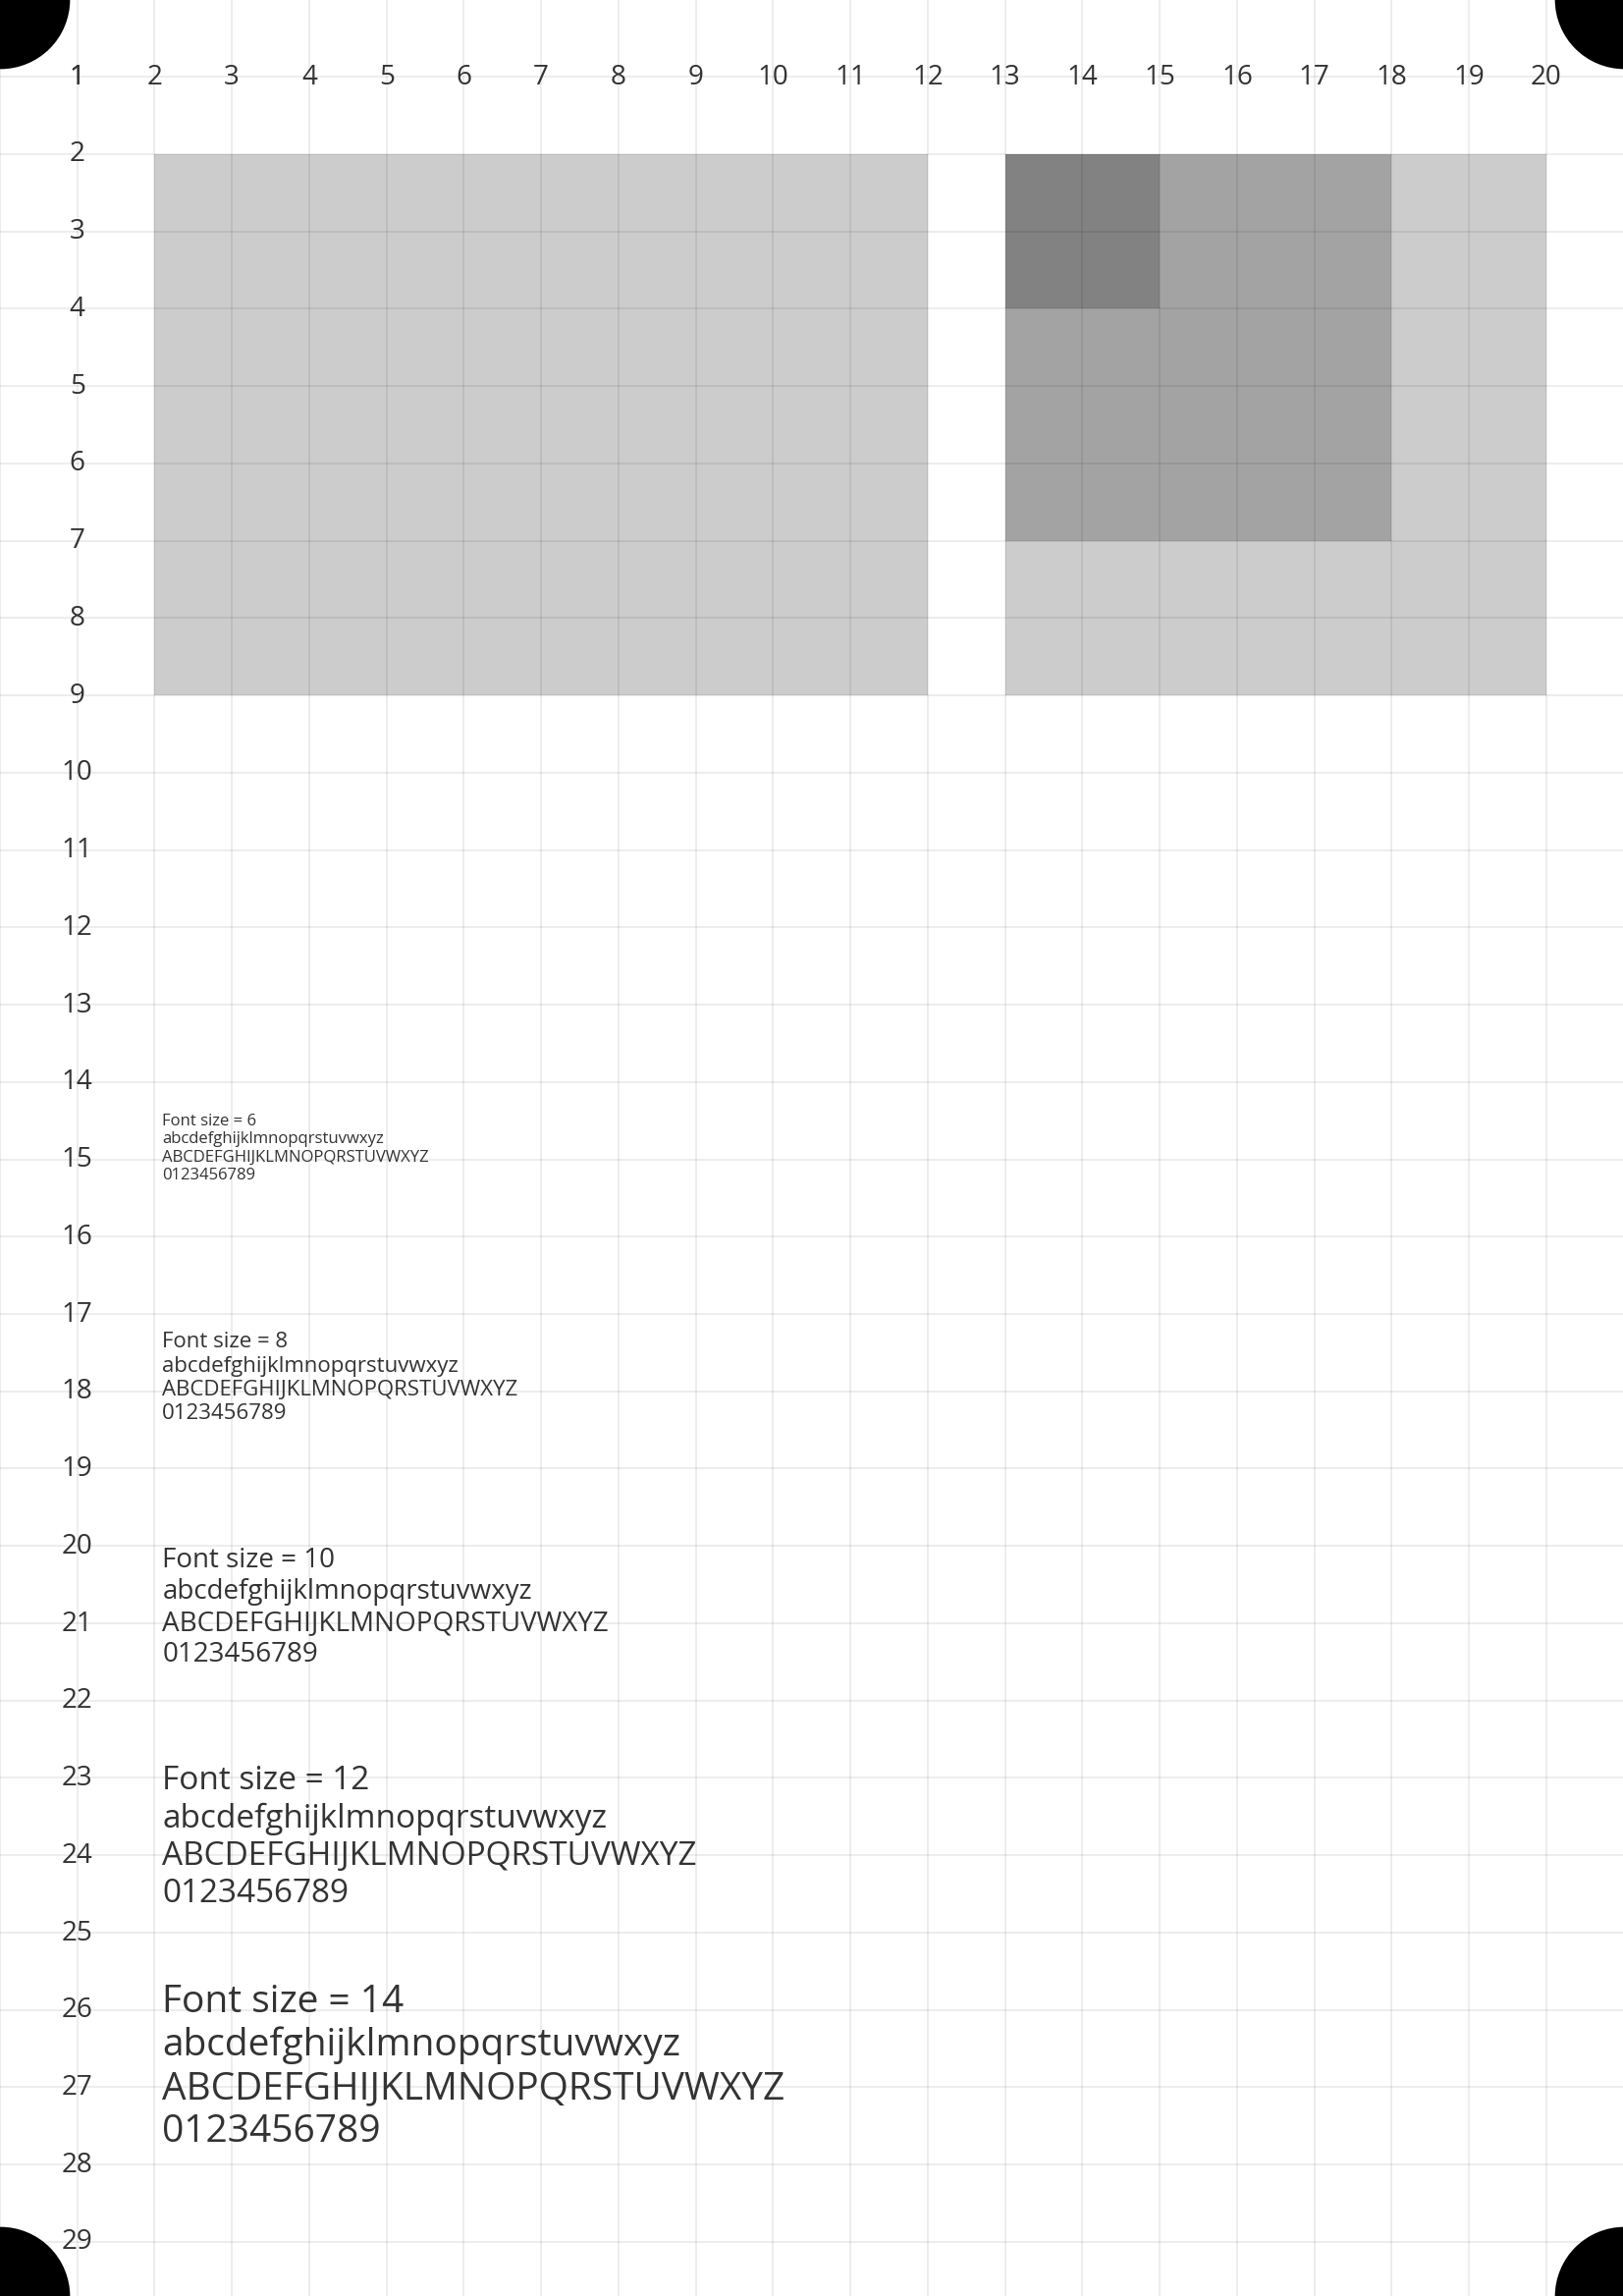

In [7]:
import string 

fig, ax = plt.subplots(figsize=(21*CM,29.7*CM))

sizes = [6, 8, 10, 12, 14]
ys = np.linspace(0.5, 0.1, len(sizes))
for y, size in zip(ys, sizes):
    ax.text(0.1, y, f'Font {size = }\n{string.ascii_lowercase}\n{string.ascii_uppercase}\n{"".join(map(str, range(10)))}', fontsize=size, transform=ax.transAxes, ha='left', va='center')
ax.scatter([0,0,1,1], [0,1,0,1], marker='.', s=10000, color='k', transform=ax.transAxes)

ax.spines[['left', 'bottom', 'top', 'right']].set_visible(False)
ax.set(xlim=[0, 21], ylim=[0, 29.7], xticks=np.arange(0, 22), yticks=np.arange(0, 30), xticklabels=[], yticklabels=[])
ax.tick_params(axis='both', which='both', length=0)
ax.grid(color='k', alpha=0.5, linewidth=0.1)
ax.invert_yaxis()

xlabels = [ax.text(xtick, 1, str(xtick), transform=ax.transData, ha='center', va='center') for xtick in ax.get_xticks()[1:-1]]
ylabels = [ax.text(1, ytick, str(ytick), transform=ax.transData, ha='center', va='center') for ytick in ax.get_yticks()[1:]]

rects = [
    plt.Rectangle((2,  2), 10, 7,  transform=ax.transData, edgecolor='none', facecolor='k', alpha=0.2),
    plt.Rectangle((13, 2), 7, 7, transform=ax.transData, edgecolor='none', facecolor='k', alpha=0.2),
    plt.Rectangle((13, 2), 5, 5, transform=ax.transData, edgecolor='none', facecolor='k', alpha=0.2),
    plt.Rectangle((13, 2), 2, 2, transform=ax.transData, edgecolor='none', facecolor='k', alpha=0.2),
]
for rect in rects:
    ax.add_patch(rect)

fig.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)

if SAVEFIG:
    fig.savefig(FIGPATH / 'fonts-proof.svg')

# Colour maps

In [8]:
cet18 = plt.get_cmap('cet_CET_L18')
summer = plt.get_cmap('summer')
ylgn = plt.get_cmap('YlGn')
tab10 = plt.get_cmap('tab10')

x1 = np.linspace(0, 0.2, 100)
x2 = np.linspace(0.5, 1, 100)
x = np.concatenate([x1, x2])

rgb = np.concatenate([cet18(x1)[:, :3], ylgn(x2)[:, :3]], axis=0)

cdict = {
    'red': np.array([x, rgb[:, 0], rgb[:, 0]]).T,
    'green': np.array([x, rgb[:, 1], rgb[:, 1]]).T,
    'blue': np.array([x, rgb[:, 2], rgb[:, 2]]).T
}

# mycmap = LinearSegmentedColormap('white-yellow-green', N=256, segmentdata=cdict)

---

# Load data

In [9]:
participants = pd.read_csv('/RAID1/jupytertmp/mcm/data/participants.csv')

In [10]:
fname = '/RAID1/jupytertmp/mcm/data/data_group-tum.joblib'
group = joblib.load(fname)

In [11]:
len(group)

20

In [12]:
resolution = 'fsaverage'
fsaverage = datasets.fetch_surf_fsaverage(mesh=resolution, data_dir='/RAID1/jupytertmp/mcm/data/external')
fsaverage5 = datasets.fetch_surf_fsaverage(mesh='fsaverage5', data_dir='/RAID1/jupytertmp/mcm/data/external') # this is for yeo

annot_lh = f'/RAID1/jupytertmp/mcm/data/external/schaefer/{resolution}/lh.Schaefer2018_400Parcels_7Networks_order.annot'
annot_rh = f'/RAID1/jupytertmp/mcm/data/external/schaefer/{resolution}/rh.Schaefer2018_400Parcels_7Networks_order.annot'
schaefer = pymcm.plotting.utils.load_annot(annot_lh, annot_rh)

annot_lh = f'/RAID1/jupytertmp/mcm/data/external/yeo/lh.Yeo2011_7Networks_N1000.annot'
annot_rh = f'/RAID1/jupytertmp/mcm/data/external/yeo/rh.Yeo2011_7Networks_N1000.annot'
yeo = pymcm.plotting.utils.load_annot(annot_lh, annot_rh)

NETWORKS = pymcm.data.Yeo6Networks
NETWORKS7 = pymcm.data.Yeo7Networks
networks_yeo_ordered = NETWORKS.reorder(np.argsort(NETWORKS.get_list('id')))
networks_yeo7_ordered = NETWORKS7.reorder(np.argsort(NETWORKS7.get_list('id')))

[fetch_surf_fsaverage] Dataset found in /RAID1/jupytertmp/mcm/data/external/fsaverage


In [105]:
dl = np.loadtxt('/RAID1/jupytertmp/mcm/data/fsa5-geodistance/lh.Schaefer2018_400Parcels_7Networks_geodistance.txt', delimiter=',')
dr = np.loadtxt('/RAID1/jupytertmp/mcm/data/fsa5-geodistance/rh.Schaefer2018_400Parcels_7Networks_geodistance.txt', delimiter=',')

idcs_left, idcs_right = np.split(np.isin(np.arange(1, 401), group['roi_template']), 2)

schaefer_distance = {
    'left': dl[np.ix_(idcs_left, idcs_left)],
    'right': dl[np.ix_(idcs_right, idcs_right)]
}

# Excluded regions

In [ ]:
table = group['table']
# table[table.roi.isin]

table.loc[(~table.roi.isin(group['roi_template'])), :].shape

# 1. Average data

---

In [ ]:
order = (
    pd.DataFrame(dict(n=np.arange(group['net_template'].size)), index=group['net_template'])
    .loc[networks_yeo_ordered.get_list('name'), 'n']
    .to_numpy()
)

In [ ]:
# coordinates
coords = (
    pd.DataFrame(dict(net=group['net_template'][order], coord=np.linspace(0, 1, group['net_template'].size)))
    .groupby('net', sort=False)
    .agg(['min', 'max'])
    .values
)
coords[:-1, 1] = coords[1:, 0]

## Connectivity

In [ ]:
# m = (group['fc'] * (group['sc'] > 0))[np.ix_(order,order)]
m = group['connectivity'][np.ix_(order,order)]

fig, ax = plt.subplots(figsize=(5*CM,5*CM))
norm = colors.PowerNorm(gamma=1)
sns.heatmap(m, square=True, cmap='cet_CET_L1_r', cbar=False, rasterized=True, ax=ax, norm=norm)
ax.set(xticks=[], yticks=[])
ax.set_xlabel('Region')
ax.set_ylabel('Region')
ax.set_title('Connectivity', x=-0.02, y=1.02, transform=ax.transAxes, ha='left') # 
ax.text(0.6, 1.03, '(FC × SC)', transform=ax.transAxes, fontsize=6, ha='left')

for i, (start, end) in enumerate(coords):

    vpatch = plt.Rectangle((-0.02,1-start), width=0.02, height=start-end, transform=ax.transAxes, clip_on=False, edgecolor=None, facecolor=networks_yeo_ordered.get_palette()(i), rasterized=True)
    hpatch = plt.Rectangle((start,-0.02), width=end-start, height=0.02, transform=ax.transAxes, clip_on=False, edgecolor=None, facecolor=networks_yeo_ordered.get_palette()(i), rasterized=True)

    ax.add_patch(vpatch)
    ax.add_patch(hpatch)

norm = colors.Normalize(vmin=m.min(), vmax=m.max())
# mappable = plt.cm.ScalarMappable(norm=norm, cmap='cet_CET_L1_r')
# cax = ax.inset_axes([0.8, 1.02, 0.2, 0.02], transform=ax.transAxes)
# cbar = fig.colorbar(mappable, cax=cax, orientation='horizontal', ticks=[0, 0.7])
# cbar.outline.set_visible(False)
# cbar.ax.tick_params(size=0, labelsize=6, pad=0)
# cbar.ax.set_xticklabels(['0', '.7'])
# cbar.ax.xaxis.set_ticks_position('top')
mappable = plt.cm.ScalarMappable(norm=norm, cmap='cet_CET_L1_r')
cax = ax.inset_axes([1.02, 0, 0.02, 0.2], transform=ax.transAxes)
cbar = fig.colorbar(mappable, cax=cax, orientation='vertical', ticks=[0, 0.7])
cbar.outline.set_visible(False)
cbar.ax.tick_params(size=0, labelsize=6, pad=0)
cbar.ax.set_yticklabels(['0', '.7'])
# cbar.ax.xaxis.set_ticks_position('right')

# ax.axis('off')

if SAVEFIG:
    fig_path = FIGPATH / '1_avg_data-fcXsc.svg'
    fig.savefig(fig_path)

## Energy difference

In [ ]:
cet_d1 = plt.colormaps['cet_CET_D1']
cls = [pymcm.colours.greyscale(cet_d1(i)[:-1]) for i in np.linspace(0, 0.5, 100, endpoint=False)] + [cet_d1(i) for i in np.linspace(0.5, 1, 100)]
halfgrey_CETd1 = colors.LinearSegmentedColormap.from_list(name='', colors=cls, N=1000)

cet_l18 = plt.colormaps['cet_CET_L18']
cls = [pymcm.colours.greyscale(cet_l18(i)[:-1]) for i in np.linspace(1, 0, 100)] + [cet_l18(i) for i in np.linspace(0, 1, 100)]
halfgrey_CETl18 = colors.LinearSegmentedColormap.from_list(name='', colors=cls, N=1000)


In [ ]:
m = group['logratio'][np.ix_(order,order)].copy()
m[m > 0] = 0
m = np.abs(m)

cmap = 'cet_CET_L1_r'

fig, ax = plt.subplots(figsize=(5*CM,5*CM))
sns.heatmap(m, square=True, cmap=cmap, cbar=False, rasterized=True)
ax.set(xticks=[], yticks=[])
ax.set_xlabel('Region')
ax.set_ylabel('Region')
title = ax.set_title('Energy difference', x=-0.02, y=1.02, transform=ax.transAxes, ha='left')

for i, (start, end) in enumerate(coords):

    vpatch = plt.Rectangle((-0.02,1-start), width=0.02, height=start-end, transform=ax.transAxes, clip_on=False, edgecolor=None, facecolor=networks_yeo_ordered.get_palette()(i), rasterized=True)
    hpatch = plt.Rectangle((start,-0.02), width=end-start, height=0.02, transform=ax.transAxes, clip_on=False, edgecolor=None, facecolor=networks_yeo_ordered.get_palette()(i), rasterized=True)

    ax.add_patch(vpatch)
    ax.add_patch(hpatch)

norm = colors.Normalize(vmin=m.min(), vmax=m.max())
# mappable = plt.cm.ScalarMappable(norm=norm, cmap=halfgrey_CETl18.reversed())
# cax = ax.inset_axes([0.8, 1.02, 0.2, 0.02], transform=ax.transAxes)
# cbar = fig.colorbar(mappable, cax=cax, orientation='horizontal', ticks=[-0.9, 0.9])
# cbar.outline.set_visible(False)
# cbar.ax.tick_params(size=0, labelsize=6, pad=0)
# cbar.ax.set_xticklabels(['-.9', '.9'])
# cbar.ax.xaxis.set_ticks_position('top')

mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
# cax = ax.inset_axes([1.02, 0.4, 0.02, 0.2], transform=ax.transAxes)
cax = ax.inset_axes([1.02, -0, 0.02, 0.2], transform=ax.transAxes)
cbar = fig.colorbar(mappable, cax=cax, orientation='vertical', ticks=[0, 0.9])
cbar.outline.set_visible(False)
cbar.ax.tick_params(size=0, labelsize=6, pad=0)
cbar.ax.set_yticklabels(['0', '.9'])
cbar.ax.yaxis.set_ticks_position('right')

if SAVEFIG:
    fig_path = FIGPATH / '1_avg_data-logratio.svg'
    fig.savefig(fig_path)

## Undirected

In [ ]:
x1 = y1 = 200
delta = 50
x2 = y2 = x1 + delta

In [ ]:
m = group['undirected'][np.ix_(order,order)]

fig, ax = plt.subplots(figsize=(5*CM,5*CM))
norm = colors.PowerNorm(gamma=1)
sns.heatmap(m, square=True, cmap='cet_CET_L1_r', cbar=False, rasterized=True, norm=norm) #vmin=0, vmax=0.2
ax.set(xticks=[], yticks=[])
ax.set_xlabel('Region')
ax.set_ylabel('Region')
ax.set_title('Undirected', x=-0.02, y=1.02, transform=ax.transAxes, ha='left')

# network labels
for i, (start, end) in enumerate(coords):
    
    vpatch = plt.Rectangle((-0.02,1-start), width=0.02, height=start-end, transform=ax.transAxes, clip_on=False, edgecolor=None, facecolor=networks_yeo_ordered.get_palette()(i), rasterized=True)
    hpatch = plt.Rectangle((start,-0.02), width=end-start, height=0.02, transform=ax.transAxes, clip_on=False, edgecolor=None, facecolor=networks_yeo_ordered.get_palette()(i), rasterized=True)

    ax.add_patch(vpatch)
    ax.add_patch(hpatch)

# Inset zoom plot 
axins = ax.inset_axes(
    bounds=[0.6, 0.6, 0.5, 0.5],
    xlim=(x1, x2), 
    ylim=(y1, y2),
    frameon=True
    )
axins.invert_yaxis()

axins.pcolormesh(m, cmap='cet_CET_L1_r', norm=norm, rasterized=True)
axins.set(xticks=[], yticks=[])
rect, lines = ax.indicate_inset([x1, y1, delta, delta], axins, transform=ax.transData, edgecolor='k', linewidth=1)
for line in lines:
    line.set(linewidth=1, color='k')
for obj in axins.get_default_bbox_extra_artists():
    obj.set(edgecolor='k', linewidth=1)
axins.text(0, 1.01, 'symmetric', fontsize=6, ha='left', va='bottom', transform=axins.transAxes)


# Colorbar
mappable = plt.cm.ScalarMappable(norm=norm, cmap='cet_CET_L1_r')
cax = ax.inset_axes([1.02, 0, 0.02, 0.2], transform=ax.transAxes)
cbar = fig.colorbar(mappable, cax=cax, orientation='vertical', ticks=[0, 0.6])
cbar.outline.set_visible(False)
cbar.ax.tick_params(size=0, labelsize=6, pad=0)
cbar.ax.set_yticklabels(['0', '.6'])
cbar.ax.yaxis.set_ticks_position('right')

if SAVEFIG:
    fig_path = FIGPATH / '1_avg_data-undirected.svg'
    fig.savefig(fig_path)

## Directed

In [ ]:
m = group['directed'][np.ix_(order,order)]

cmap = 'cet_CET_L18' # cet_CET_L18 RdPu BuPu

fig, ax = plt.subplots(figsize=(5*CM,5*CM))
norm = colors.PowerNorm(gamma=0.6)
sns.heatmap(m, square=True, cmap=cmap, cbar=False, rasterized=True, norm=norm)
ax.set(xticks=[], yticks=[])
ax.set_xlabel('Target region')
ax.set_ylabel('Source region')
ax.set_title('Directed', x=-0.02, y=1.02, transform=ax.transAxes, ha='left')

# network labels
for i, (start, end) in enumerate(coords):
    
    vpatch = plt.Rectangle((-0.02,1-start), width=0.02, height=start-end, transform=ax.transAxes, clip_on=False, edgecolor=None, facecolor=networks_yeo_ordered.get_palette()(i), rasterized=True)
    hpatch = plt.Rectangle((start,-0.02), width=end-start, height=0.02, transform=ax.transAxes, clip_on=False, edgecolor=None, facecolor=networks_yeo_ordered.get_palette()(i), rasterized=True)

    ax.add_patch(vpatch)
    ax.add_patch(hpatch)

# Inset zoom plot 
axins = ax.inset_axes(
    bounds=[0.6, 0.6, 0.5, 0.5],
    xlim=(x1, x2), 
    ylim=(y1, y2),
    frameon=True
    )
axins.invert_yaxis()

axins.pcolormesh(m, cmap=cmap, norm=norm, rasterized=True)
axins.set(xticks=[], yticks=[])
rect, lines = ax.indicate_inset([x1, y1, delta, delta], axins, transform=ax.transData, edgecolor='k', linewidth=1)
for line in lines:
    line.set(linewidth=1, color='.2')
for obj in axins.get_default_bbox_extra_artists():
    obj.set(edgecolor='.2', linewidth=1)
axins.text(0, 1.01, 'asymmetric', fontsize=6, ha='left', va='bottom', transform=axins.transAxes)

# Colorbar
mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cax = ax.inset_axes([1.02, 0, 0.02, 0.2], transform=ax.transAxes)
cbar = fig.colorbar(mappable, cax=cax, orientation='vertical', ticks=[0, 0.1])
cbar.outline.set_visible(False)
cbar.ax.tick_params(size=0, labelsize=6, pad=0)
cbar.ax.set_yticklabels(['0', '.1'])
cbar.ax.yaxis.set_ticks_position('right')

if SAVEFIG:
    fig_path = FIGPATH / '1_avg_data-directed.svg'
    fig.savefig(fig_path)

# 2. Yeo netwokrs figures

## In/out barplot

In [ ]:
df = pd.concat([
    pd.DataFrame({
        'subject':  sub.name, 
        'network':  sub['netstats']['labels_order'],
        'afferent': sub['netstats']['degree_in_percent'] * 100, 
        'efferent': sub['netstats']['degree_out_percent'] * 100,
        })
    .melt(
        id_vars=['subject', 'network'], 
        var_name='direction', 
        value_name='degree'
    ) for sub in group.iterraw()
])

grouped = df.loc[:, ['network', 'direction', 'degree']].groupby(['direction', 'network']).agg('median').reset_index()
grouped.index = grouped.network
order_idcs = grouped[grouped.direction == 'afferent'].degree /  grouped[grouped.direction == 'efferent'].degree
order_idcs = np.argsort(order_idcs.values)

networks_ordered = NETWORKS.reorder(order_idcs)

In [ ]:
SAVEFIG = False

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(8*CM,4*CM))

sns.barplot(
    x='network', y='degree', 
    hue='direction',
    hue_order=['efferent', 'afferent'],
    data=df,
    estimator=np.nanmean, 
    ax=ax, 
    linewidth=0, 
    capsize=0, 
    err_kws={'color': '.2', 'linewidth': 0.5}, 
    order=networks_ordered.get_list('name'),
    zorder=2
)

# ax.axhline(50, linewidth=0.5, color='.7', linestyle=':', zorder=0)
# ax.set_ylim(0,100)

ax.set_ylabel('% connections\nwith other nets')
ax.set_xlabel(None)

palette = networks_ordered.get_desat_palette(alpha=0.6)
for i, bar in enumerate(ax.patches):
    bar.set_facecolor(palette(i))
    
legend = ax.legend(frameon=False, loc=[0, 1], fontsize=6, ncols=2, columnspacing=1, handletextpad=0.2)
ax.get_legend().legend_handles[0].set_color('#7D7D7D')
ax.get_legend().legend_handles[1].set_color('#D4D4D4')

ax.tick_params(axis='both', left=False, bottom=False)
ax.tick_params(axis='y', pad=0)
ax.set_xticklabels(networks_ordered.get_list('short_name'), rotation=0, ha='center', va='center')

ax.set_yticks([25, 50, 75])
ax.grid(axis='y', linewidth=0.5, color='.7', linestyle=':', zorder=0)
# ax.set_yticklabels(ax.get_yticklabels())

ax.spines[['top', 'right', 'left']].set_visible(False)
# ax.spines.right.set_visible(False)


if SAVEFIG:
    fig_path = FIGPATH / '2_yeonets-networks_barplot.svg'
    fig.savefig(fig_path)

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(4*CM,7*CM))

sns.barplot(
    x='degree', y='network', 
    hue='direction',
    hue_order=['efferent', 'afferent'],
    data=df,
    estimator=np.nanmean, 
    ax=ax, 
    linewidth=0, 
    capsize=0, 
    err_kws={'color': '.2', 'linewidth': 0.5}, 
    order=networks_ordered.get_list('name'),
    zorder=2, orient='h'
)

# ax.axhline(50, linewidth=0.5, color='.7', linestyle=':', zorder=0)
# ax.set_ylim(0,100)

ax.set_xlabel('% connections\nwith other nets')
ax.set_ylabel(None)

palette = networks_ordered.get_desat_palette(alpha=0.6)
for i, bar in enumerate(ax.patches):
    bar.set_facecolor(palette(i))
    
legend = ax.legend(frameon=False, loc=[0, 1], fontsize=6, ncols=2, columnspacing=1, handletextpad=0.2)
ax.get_legend().legend_handles[0].set_color('#7D7D7D')
ax.get_legend().legend_handles[1].set_color('#D4D4D4')

ax.tick_params(axis='both', left=False, bottom=False)
ax.tick_params(axis='x', pad=0)
ax.set_yticklabels(networks_ordered.get_list('short_name'), rotation=0, ha='center', va='center')

ax.set_xticks([25, 50, 75])
ax.grid(axis='x', linewidth=0.5, color='.7', linestyle=':', zorder=0)
# ax.set_yticklabels(ax.get_yticklabels())

ax.spines[['top', 'bottom', 'right']].set_visible(False)
# ax.spines.right.set_visible(False)


if SAVEFIG:
    fig_path = FIGPATH / '2_yeonets-networks_barplot.svg'
    fig.savefig(fig_path)

## Self connections small piecharts

In [ ]:
self_connections = np.mean([sub['netstats']['self_conns_percent'] for sub in group.iterraw()], axis=0)

In [ ]:
for value, net in zip(self_connections, NETWORKS):

    to_plot = [value, 1-value]
    to_colour = [net.colour, (.9, .9, .9, 1)]
    to_label = [f'{value:.0%}', '']
    # rot = 0 if value > 0.3 else 90 - np.degrees(value * np.pi)

    radius = 1
    rot = 270 - np.degrees(value * np.pi)
    label_x = np.cos(np.radians(rot)) - 0.2
    label_y = np.sin(np.radians(rot)) + 0.2

    fig, ax = plt.subplots(figsize=(0.6*CM,0.6*CM))
    patches, text_labels = ax.pie(to_plot, labels=to_label,
        labeldistance=1.7,
        radius=radius,
        startangle= 270 - np.degrees(value * np.pi),
        colors=to_colour,
        textprops=dict(va='center', ha='center', fontsize=8, color='.3'), #rotation=rot, x=label_x, y=label_y),
        wedgeprops = {'linewidth': 0}
        )
    
    fig.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)

    if SAVEFIG:
        fig_path = FIGPATH / f'2_yeonets-self_{net.nice_name}_pie.svg'
        fig.savefig(fig_path)

## In/out piecharts

### Outputs i.e. efferent

Outputs of each network arethe **ROWS** of the network average matrix 
- iterate over **ROWS** of the matrix and make the pie chart
- **ROWS** should add up to 1
- by default, for loop iterates over the rows of the matrix

In [ ]:
m = group['netavg_wrt_outputs'].copy()
m = m[np.ix_(order_idcs, order_idcs)]
np.fill_diagonal(m, 0)

# assert np.allclose(m.sum(axis=1), 1)

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(1.5,1.5))

sns.heatmap(m*100, 
    mask=np.eye(m.shape[0]),
    cmap='cet_CET_L18',# vmax=net_ec_rounded.max() + 2, # center=0,
    square=True, cbar_kws={"shrink": 0.8, 'orientation': 'horizontal', 'location': 'top'},
    linewidths=0, annot=False, annot_kws={'fontsize': 6}, #fmt='.0f'
    ax=ax)

ax.tick_params(axis='both', left=False, bottom=False)
ax.set_yticks(np.arange(0,6) + 0.5)
ax.set_yticklabels(networks_ordered.get_list('nice_name'), rotation=0)
ax.set_xticklabels(networks_ordered.get_list('short_name'), rotation=0)

ax.set(facecolor='.7')

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(size=0, labelsize=6)
# cbar.ax.set_xticks([0, 10, 20, 25])

palette = networks_ordered.get_palette()
for i, ticklabel in enumerate(ax.get_yticklabels()):
    ticklabel.set_color(palette(i))
for i, ticklabel in enumerate(ax.get_xticklabels()):
    ticklabel.set_color(palette(i))

In [ ]:
fig, axs = plt.subplots(1,6, figsize=(5,2), layout='constrained')

for row, label, ax in zip(m, networks_ordered.get_list('nice_name'), axs):
    mask = row != 0
    to_plot = row[mask]
    to_label = np.array(networks_ordered.get_list('short_name'))[mask]
    to_colour = [networks_ordered.get_palette()(i) for i, include in zip(range(6), mask) if include]
    explode = [0.1 if i == to_plot.max() else 0 for i in to_plot]

    patches, text_labels = ax.pie(to_plot, #labels=to_label, 
        rotatelabels=False,
        labeldistance=0.7,
        explode=explode,
        startangle=90,
        colors=to_colour,
        radius=1.3,
        textprops={'va': 'center', 'ha': 'center', 'fontsize': 6},
        wedgeprops = {'linewidth': 0}
        )
    title = ax.set_title(label, fontdict={'fontsize': 10})
    # title.set_color(networks_ordered[label].hex_colour)

In [ ]:
for i, net in enumerate(NETWORKS):
    print(f'{net.nice_name} outputs to itself: {np.round(group["netavg_wrt_outputs"][i,i]*100, 2)}%')

### Inputs i.e. afferent

Inputs of each network arethe **COLUMNS** of the network average matrix 
- iterate over **COLUMNS** of the matrix and make the pie chart
- transpose the matrix and iterate over rows
- **COLUMNS** should add up to 1

In [ ]:
m = group['netavg_wrt_inputs'].copy()
m = m[np.ix_(order_idcs, order_idcs)]
np.fill_diagonal(m, 0)

# assert np.allclose(m.sum(axis=0), 1)

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(1.5,1.5))

sns.heatmap(m*100, 
    mask=np.eye(m.shape[0]),
    cmap='cet_CET_L18',# vmax=net_ec_rounded.max() + 2, # center=0,
    square=True, cbar_kws={"shrink": 0.8, 'orientation': 'horizontal', 'location': 'top'},
    linewidths=0, annot=False, annot_kws={'fontsize': 6}, #fmt='.0f'
    ax=ax)

ax.tick_params(axis='both', left=False, bottom=False)
ax.set_yticks(np.arange(0,6) + 0.5)
ax.set_yticklabels(networks_ordered.get_list('nice_name'), rotation=0)
ax.set_xticklabels(networks_ordered.get_list('short_name'), rotation=0)

ax.set(facecolor='.7')

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(size=0, labelsize=6)
# cbar.ax.set_xticks([0, 10, 20, 25])

palette = networks_ordered.get_palette()
for i, ticklabel in enumerate(ax.get_yticklabels()):
    ticklabel.set_color(palette(i))
for i, ticklabel in enumerate(ax.get_xticklabels()):
    ticklabel.set_color(palette(i))


In [ ]:
fig, axs = plt.subplots(1,6, figsize=(5,2), layout='constrained')

for row, label, ax in zip(m.T, networks_ordered.get_list('nice_name'), axs):
    mask = row != 0
    to_plot = row[mask]
    to_label = np.array(networks_ordered.get_list('short_name'))[mask]
    to_colour = [networks_ordered.get_palette()(i) for i, include in zip(range(6), mask) if include]
    explode = [0.1 if i == to_plot.max() else 0 for i in to_plot]

    patches, text_labels = ax.pie(to_plot,# labels=to_label, 
        rotatelabels=False,
        labeldistance=0.7,
        explode=explode,
        startangle=90,
        colors=to_colour,
        radius=1.3,
        textprops={'va': 'center', 'ha': 'center', 'fontsize': 6},
        wedgeprops = {'linewidth': 0}
        )
    title = ax.set_title(label, fontdict={'fontsize': 10})
    # title.set_color(networks_ordered[label].hex_colour)

In [ ]:
for i, net in enumerate(NETWORKS):
    print(f'{net.nice_name} inputs from itself: {np.round(group["netavg_wrt_inputs"][i,i]*100, 2)}%')

## Regions graph

In [ ]:
m = group['directed'] + group['directed'].T
# m = group['undirected']
colours = [NETWORKS[net].hex_colour() for net in group['net_template']]

G = gt.Graph(directed=False)
vertices = list(G.add_vertex(n=m.shape[0]))
for i, j in zip(*m.nonzero()):
    G.add_edge(vertices[i], vertices[j])

vertex_colours = G.new_vertex_property(value_type='string', vals=colours)
weights = G.new_edge_property(value_type='double', vals=m[m.nonzero()])
vertex_names = G.new_vertex_property(value_type='double', vals=group['roi_template'])

state = gt.minimize_nested_blockmodel_dl(G)
state.draw(
    bg_color='white', 
    vertex_text=vertex_names, 
    vertex_fill_color=vertex_colours, 
    vertex_color=[0,0,0,0], 
    ink_scale=1,
    edge_pen_width=weights,
    output_size=(500,500), 
);

## Nets conn matrix 

In [ ]:
m = group['netavg_wrt_mixed']
# group.sub031['netavg_nets_names']

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(5*CM,5*CM))

cmap = 'cet_CET_L18'

sns.heatmap(m, 
    mask=np.eye(m.shape[0]),
    cmap=cmap,
    cbar=False,
    square=True,
    linewidths=0,
    ax=ax)

ax.tick_params(axis='both', left=False, bottom=False)
ax.set_yticks(np.arange(0,6) + 0.5)
ax.set_yticklabels(NETWORKS.get_list('nice_name'), rotation=0)
ax.set_xticklabels(NETWORKS.get_list('short_name'), rotation=0)

ax.set(facecolor='.7')

# cbar = ax.collections[0].colorbar
# cbar.ax.tick_params(size=0, labelsize=6)
# # cbar.ax.set_xticks([0, 10, 20, 25])

# Colorbar
norm = colors.Normalize(vmin=m.min(), vmax=m.max())
mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cax = ax.inset_axes([1.05, 0, 0.05, 0.3], transform=ax.transAxes)
cbar = fig.colorbar(mappable, cax=cax, orientation='vertical', ticks=[0, 0.2])
cbar.outline.set_visible(False)
cbar.ax.tick_params(size=0, labelsize=6, pad=0)
cbar.ax.set_yticklabels(['0', '.2'])
cbar.ax.yaxis.set_ticks_position('right')

palette = NETWORKS.get_palette()
for i, ticklabel in enumerate(ax.get_yticklabels()):
    ticklabel.set_color(palette(i))
for i, ticklabel in enumerate(ax.get_xticklabels()):
    ticklabel.set_color(palette(i))

if SAVEFIG:
    fig_path = FIGPATH / '2_yeonets_conn_matrix.svg'
    fig.savefig(fig_path, transparent=False)

In [ ]:
group.sub031['netavg_nets_names']

## Nets Graph

In [ ]:
m = group['netavg_wrt_mixed'].copy()
# m = bct.threshold_proportional(group['netavg_wrt_mixed'], 0.5)

np.fill_diagonal(m, 0)
G = gt.Graph(directed=True)

vertices = list(G.add_vertex(n=6))
for i, j in zip(*m.nonzero()):
    G.add_edge(vertices[i], vertices[j])

weights = G.new_edge_property(value_type='float', vals=m[m.nonzero()] * 30)
vertex_names = G.new_vertex_property(value_type='string', vals=NETWORKS.get_list('short_name'))

colours = [net.hex_colour() for net in NETWORKS]
vertex_colours = G.new_vertex_property(value_type='string', vals=colours)

xy = [
    [0, 0],
    [1.5, -0.1],
    [2.5, 0.5],
    [2.5, -1.5],
    [2.7, 1.5],
    [3.5, -0.3],
]

pos = G.new_vertex_property(value_type='vector<float>', vals=xy)

state = gt.minimize_blockmodel_dl(G)
state.draw(
    # pos=pos,
    bg_color='white', 
    # vertex_text=vertex_names, 
    vertex_fill_color=vertex_colours, 
    vertex_color=[0]*6, 
    ink_scale=1,
    edge_pen_width=weights,
    output_size=(300,300), 
);

#     # output='/home/tumnic/rbelenya/mcm/notebooks/paper/vis_graph.png')


## Nets Sankey

In [ ]:
# m = group['netavg_wrt_mixed'].copy()
m = bct.threshold_proportional(group['netavg_wrt_mixed'], 1)
np.fill_diagonal(m, 0)

sources, targets = list(zip(*itertools.product([0,1,2,3,4,5], [0,1,2,3,4,5])))
values = m.flatten()

sources, targets = np.array(sources), np.array(targets)

targets += 6

assert sources.size == values.size == targets.size

In [ ]:
SAVEFIG

In [ ]:
import plotly.graph_objects as go
import plotly.io as pio
# import kaleido 

pio.renderers.default = "notebook"

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 30,
      thickness = 15,
      line = dict(width = 0, color='black'),
      # label = NETWORKS.get_list('nice_name')*2,
      color = [net.hex_colour() for net in NETWORKS] * 2,
    ),
    link = dict(
      arrowlen=0,
      source=sources, # indices correspond to labels, eg A1, A2, A1, B1, ...
      target=targets,
      value=values,
      color=[f'rgba{NETWORKS.nets[i].rgba_colour(alpha=0.3)}' for i in sources],
      label=['a', 'b']
  )
)])

fig.update_layout(font_size=10, width=300, height=500, margin=dict(b=10, l=10, r=10, t=10))
fig.show()

if SAVEFIG:
  fig_path = FIGPATH / '2_yeonets-networks_sankey.svg'
  fig.write_image(fig_path, engine='kaleido')

# 2. Visual system

## Regions

In [ ]:
regions = joblib.load('/RAID1/jupytertmp/mcm/data/vis_regions.joblib')

for key, value in regions.items():
    labels = value['labels']
    idcs, = np.where(np.isin(group['roi_template'], labels))
    value['idcs'] = idcs

VIS_REGIONS = pymcm.data.VisRegions

In [ ]:
regions

In [ ]:
idcs = []
labels = []

for key, val in regions.items():
    idcs.extend(val['idcs'])
    labels.extend([key] * len(val['idcs']))

idcs = np.array(idcs)
labels = np.array(labels)

directed = np.stack([sub['directed'] for sub in group.iterraw()], 2)
vis_directed = directed[np.ix_(idcs, idcs)]

grouped_diagonal_mask = pymcm.array.grouped_diagonal_mask(labels)
vis_directed[grouped_diagonal_mask, :] = 0

visavgs = []
order = [1,2,3,0,4]
vis_regions_ordered = VIS_REGIONS.reorder(order)

for i in range(vis_directed.shape[-1]):
    sums, vis_labels = pymcm.array.matrix_grouped_stat(vis_directed[:, :, i], labels, func=np.sum)
    sums = sums[np.ix_(order,order)]
    degree_in = sums.sum(axis=0, keepdims=True) # column vector
    degree_out = sums.sum(axis=1, keepdims=True) # row vector
    norm_mixed = degree_out + degree_in - sums
    visavgs.append(sums / norm_mixed)

visavgs = np.array(visavgs)
visavg_wrt_mixed = visavgs.mean(axis=0)

# visavg_wrt_mixed = bct.threshold_proportional(visavg_wrt_mixed, 0.7)

In [ ]:
null_models_dir = Path('/RAID1/jupytertmp/mcm/data/null-models/tum/directed')
null_models = []


for i, file in enumerate(null_models_dir.glob('*.npz')):
    with np.load(file) as f:

        directed = f['arr_0']
        
        vis_directed = directed[np.ix_(idcs, idcs)]
        vis_directed[grouped_diagonal_mask] = 0

        sums, vis_labels = pymcm.array.matrix_grouped_stat(vis_directed, labels, func=np.sum)
        sums = sums[np.ix_(order,order)]
        degree_in = sums.sum(axis=0, keepdims=True) # column vector
        degree_out = sums.sum(axis=1, keepdims=True) # row vector
        norm_mixed = degree_out + degree_in - sums
        null_models.append(sums / norm_mixed)
    print(i, end='\r')

null_models = np.array(null_models)

#### significant connections null models test

In [ ]:
p_matrix = np.zeros((5,5))

for i, j in itertools.product(range(5), range(5)):
    if i == j:
        continue

    score = visavg_wrt_mixed[i, j]
    distribution = null_models[:, i, j]
    p_matrix[i, j] = 1 - stats.percentileofscore(distribution, score) / 100

p_matrix_fdr = stats.false_discovery_control(np.nan_to_num(p_matrix).flatten()).reshape(5,5)

In [ ]:
sns.heatmap(p_matrix_fdr, square=True, annot=True, fmt='.3f')

#### significant connections null t-test

In [ ]:
t_matrix = np.zeros((5,5))
p_matrix = np.zeros((5,5))
# population_mean = np.mean(visavgs[visavgs > 0])
# population_mean = np.quantile(visavgs[visavgs > 0], 0.25)
population_mean = 0

for i, j in itertools.product(range(5), range(5)):
    test = stats.ttest_1samp(visavgs[:, i, j], popmean=population_mean, alternative='greater')
    t_matrix[i, j] = test.statistic
    p_matrix[i, j] = test.pvalue

p_matrix_fdr = stats.false_discovery_control(np.nan_to_num(p_matrix).flatten()).reshape(5,5)

In [ ]:
sns.heatmap(p_matrix_fdr, square=True, annot=True, fmt='.3f')

### t tests

In [ ]:
labels = vis_regions_ordered.get_list('nice_name')
product = itertools.product(labels, labels)
combos = ['-'.join(item) for item in product]
labels_matrix = np.array(combos).reshape(5,5)
comparison_idcs = list(itertools.combinations(range(5), 2))

tests = []
test_labels = []
for comparison_idc in comparison_idcs:

    j, k = comparison_idc

    x = visavgs[:, j, k]
    y = visavgs[:, k, j]
    x_label = labels_matrix[j, k]
    y_label = labels_matrix[k, j]

    test = stats.wilcoxon(x, y)
    # test = stats.wilcoxon(x - y)

    tests.append(test)
    test_labels.append(f'{x_label} vs {y_label}')

    print(labels_matrix[j,k], test.statistic, test.pvalue)

pvals = [test.pvalue for test in tests]
pvals_adjusted = stats.false_discovery_control(pvals)
significant_idcs = [idc for idc, pval in zip(comparison_idcs, pvals_adjusted) if pval < 0.05]

In [ ]:
for label, pval, pval_adj in zip(test_labels, pvals, pvals_adjusted):
    sig = '*' if pval_adj < 0.05 else ' '
    print(f'{label:>30}: {sig} {pval_adj} ({pval:.3f})')

## Conn matrix

In [ ]:
SAVEFIG = True

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(5*CM,5*CM))

cmap = 'cet_CET_L18'
sns.heatmap(
    visavg_wrt_mixed, 
    square=True, 
    cbar=False,
    cmap=cmap, 
    # mask=np.eye(len(regions)),
    mask=p_matrix_fdr>=0.05,
    ax=ax
)

ax.set_yticklabels(vis_regions_ordered.get_list('nice_name'), rotation=0,)
ax.set_xticklabels(vis_regions_ordered.get_list('short_name'),)
ax.tick_params(left=False, bottom=False)
ax.set_facecolor('.7')

norm = colors.Normalize(vmin=visavg_wrt_mixed.min(), vmax=visavg_wrt_mixed.max())
mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cax = ax.inset_axes([1.05, 0, 0.05, 0.3], transform=ax.transAxes)
cbar = fig.colorbar(mappable, cax=cax, orientation='vertical', ticks=[0, 0.2])
cbar.outline.set_visible(False)
cbar.ax.tick_params(size=0, labelsize=6, pad=0)
cbar.ax.set_yticklabels(['0', '.2'])
cbar.ax.yaxis.set_ticks_position('right')

for ticklabels, color in zip(zip(ax.get_xticklabels(), ax.get_yticklabels()), tab10.colors):
    for ticklabel in ticklabels:
        ticklabel.set(color=color)

# Significance
for idc in significant_idcs:
    j, k = idc
    j += 0.5
    k += 0.5
    ax.plot([j, k], [k, j], color='k', alpha=0.4, linewidth=0.5) # marker='.', ms=7, mfc='k', mew=0,

    # mid = j + (k-j)/2
    # ax.text(mid, mid, '*', ha='center', va='center', alpha=0.4, transform=ax.transData)


if SAVEFIG:
    fig_path = FIGPATH / '3_vis_conn_matrix.svg'
    fig.savefig(fig_path, transparent=False)

## Graph

In [ ]:
G = gt.Graph(directed=True)
m = bct.threshold_proportional(visavg_wrt_mixed, 0.8)

vertices = list(G.add_vertex(n=5))
for i, j in zip(*m.nonzero()):
    G.add_edge(vertices[i], vertices[j])

weights = G.new_edge_property(value_type='float', vals=m[m.nonzero()] * 10)
vertex_names =G.new_vertex_property(value_type='string', vals=regions.keys())

colours = [net.hex_colour() for net in vis_regions_ordered]
vertex_colours = G.new_vertex_property(value_type='string', vals=colours)

# Original
# xy = [
#     [0, 0],
#     [1.5, -0.55],
#     [1.5, 0.8],
#     [3, -1.5],
#     [3, 1.5]
# ]

xy = [
    [0, 0],
    [1.5, -0],
    [1.6, 0.8],
    [3, -1.5],
    [3, 1.5]
]


pos = G.new_vertex_property(value_type='vector<float>', vals=xy)

state = gt.minimize_blockmodel_dl(G)
state.draw(
    pos=pos,
    bg_color='white', 
    # vertex_text=vertex_names, 
    vertex_fill_color=vertex_colours, 
    vertex_color=[0]*5, 
    ink_scale=1,
    edge_pen_width=weights,
    output_size=(120,120),
    output='/RAID1/jupytertmp/mcm/manuscript/figures/3_vis_graph.svg'
)

# 3. Motor system

In [ ]:
regions = joblib.load('/RAID1/jupytertmp/mcm/data/sm_regions.joblib')
for key, value in regions.items():
    idcs, = np.where(np.isin(group['roi_template'], value['labels']))
    value['idcs'] = idcs

SOMMOT_REGIONS = pymcm.data.SommotRegions

In [ ]:
idcs = []
labels = []

for key, val in regions.items():
    idcs.extend(val['idcs'])
    labels.extend([key] * len(val['idcs']))

idcs = np.array(idcs)
labels = np.array(labels)

directed = np.stack([sub['directed'] for sub in group.iterraw()], 2)
sommot_directed = directed[np.ix_(idcs, idcs)]

grouped_diagonal_mask = pymcm.array.grouped_diagonal_mask(labels)
sommot_directed[grouped_diagonal_mask, :] = 0

sommotavgs = []
order = [1,3,2,4,0]
sommot_regions_ordered = SOMMOT_REGIONS.reorder(order)

for i in range(sommot_directed.shape[-1]):
    sums, sommot_labels = pymcm.array.matrix_grouped_stat(sommot_directed[:, :, i], labels, func=np.sum)
    sums = sums[np.ix_(order,order)]
    degree_in = sums.sum(axis=0, keepdims=True) # column vector
    degree_out = sums.sum(axis=1, keepdims=True) # row vector
    norm_mixed = degree_out + degree_in - sums
    sommotavgs.append(sums / norm_mixed)

sommotavgs = np.array(sommotavgs)
sommotavg_wrt_mixed = sommotavgs.mean(axis=0)

# visavg_wrt_mixed = bct.threshold_proportional(visavg_wrt_mixed, 0.7)

### t tests

In [ ]:
labels = sommot_regions_ordered.get_list('nice_name')
product = itertools.product(labels, labels)
combos = ['-'.join(item) for item in product]
labels_matrix = np.array(combos).reshape(5,5)
comparison_idcs = list(itertools.combinations(range(5), 2))

tests = []
test_labels = []
for comparison_idc in comparison_idcs:

    j, k = comparison_idc

    x = sommotavgs[:, j, k]
    y = sommotavgs[:, k, j]
    x_label = labels_matrix[j, k]
    y_label = labels_matrix[k, j]

    tests.append(stats.ttest_ind(x, y))
    test_labels.append(f'{x_label} vs {y_label}')

pvals_adjusted = stats.false_discovery_control([test.pvalue for test in tests], method='by')
significant_idcs = [idc for idc, pval in zip(comparison_idcs, pvals_adjusted) if pval < 0.05]

In [ ]:
len(significant_idcs)

## Conn matrix 

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(5*CM,5*CM))

cmap = 'cet_CET_L18'
sns.heatmap(
    sommotavg_wrt_mixed, 
    square=True, 
    cbar=False,
    cmap=cmap, 
    mask=np.eye(len(regions)),
    ax=ax
)

ax.set_yticklabels(sommot_regions_ordered.get_list('nice_name'), rotation=0)
ax.set_xticklabels(sommot_regions_ordered.get_list('short_name'))
ax.tick_params(left=False, bottom=False)
ax.set_facecolor('.7')

norm = colors.Normalize(vmin=sommotavg_wrt_mixed.min(), vmax=sommotavg_wrt_mixed.max())
mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cax = ax.inset_axes([1.05, 0, 0.05, 0.3], transform=ax.transAxes)
cbar = fig.colorbar(mappable, cax=cax, orientation='vertical', ticks=[0, 0.3])
cbar.outline.set_visible(False)
cbar.ax.tick_params(size=0, labelsize=6, pad=0)
cbar.ax.set_yticklabels(['0', '.3'])
cbar.ax.yaxis.set_ticks_position('right')

for ticklabels, color in zip(zip(ax.get_xticklabels(), ax.get_yticklabels()), sommot_regions_ordered.get_palette().colors):
    for ticklabel in ticklabels:
        ticklabel.set(color=color)

# Significance
for idc in significant_idcs:
    j, k = idc
    j += 0.5
    k += 0.5
    ax.plot([j, k], [k, j], color='k', alpha=0.4, linewidth=0.5)

if SAVEFIG:
    fig_path = FIGPATH / '3_sommot_conn_matrix.svg'
    fig.savefig(fig_path, transparent=False)

## Graph

In [ ]:
G = gt.Graph(directed=True)

m = bct.threshold_proportional(sommotavg_wrt_mixed, 0.7)

vertices = list(G.add_vertex(n=5))
for i, j in zip(*m.nonzero()):
    G.add_edge(vertices[i], vertices[j])

weights = G.new_edge_property(value_type='float', vals=m[m.nonzero()] * 10)
vertex_names = G.new_vertex_property(value_type='string', vals=regions.keys())

colours = [net.hex_colour() for net in sommot_regions_ordered]
vertex_colours = G.new_vertex_property(value_type='string', vals=colours)

xy = [
    [0, 0],
    [-1, -0.2],
    [1, -0.3],
    [0.8, 1],
    [-0.1, 0.8]
]

pos = G.new_vertex_property(value_type='vector<float>', vals=xy)

state = gt.minimize_blockmodel_dl(G)
state.draw(
    pos=pos,
    bg_color='white', 
    vertex_fill_color=vertex_colours, 
    vertex_color=[0]*5, 
    ink_scale=1,
    edge_pen_width=weights,
    output_size=(150,150), 
    # output='/RAID1/jupytertmp/mcm/manuscript/figures/3_sommot_graph.svg'
)

---

# 4. Brain surface graphs 

## Schaefer parcellation

In [ ]:
hemi = 'right'

for view in ['lateral', 'medial']:

    fig, ax = plt.subplots(1,1, subplot_kw={'projection': '3d'}, constrained_layout=True, figsize=(5*CM,5*CM))

    plotting.plot_surf(fsaverage[f'infl_{hemi}'], 
                           schaefer[hemi]['atlas'], 
                           bg_map=fsaverage[f'sulc_{hemi}'], 
                           hemi=hemi, view=view, 
                           cmap=schaefer[hemi]['cmap'], 
                           darkness=1,
                        #    vmin=0, vmax=200,
                           bg_on_data=True,
                           axes=ax, figure=fig,
                           )
    ax.collections[0].set_rasterized(True)

    plotting.plot_surf_contours(fsaverage[f'infl_{hemi}'], schaefer[hemi]['atlas'],
                                colors=['k']*201, figure=fig, axes=ax)
    # ax.set_rasterization_zorder(0)
    ax.dist = 6.5

    if SAVEFIG:
        fig_path = FIGPATH / f'4_yeonets-parcellation-{view}.svg'
        fig.savefig(fig_path)

In [ ]:
networks_ordered

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(1,1), constrained_layout=True)
patches = [plt.Line2D([0],[0], color=net.colour, label=net.nice_name, marker='o', lw=0) for net in networks_yeo7_ordered]
fig.legend(patches, networks_yeo7_ordered.get_list('nice_name'), loc='center', frameon=False, alignment='center', ncol=1, fontsize=6, markerfirst=True);
ax.axis('off')

if SAVEFIG:
    fig_path = FIGPATH / '4_yeonets-networks_legend_vertical.svg'
    fig.savefig(fig_path)

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(1,1), constrained_layout=True)
patches = [plt.Line2D([0],[0], color=net.colour, label=net.nice_name, marker='o', lw=0) for net in networks_yeo7_ordered]
fig.legend(patches, networks_yeo7_ordered.get_list('nice_name'), loc='center', frameon=False, alignment='center', ncol=7, fontsize=6, columnspacing=0.1);
ax.axis('off')

if SAVEFIG:
    fig_path = FIGPATH / '4_yeonets-networks_legend_horizontal.svg'
    fig.savefig(fig_path)

## Somatomotor regions

In [ ]:
sm_tex = joblib.load('/RAID1/jupytertmp/mcm/data/sm_tex.joblib')
surf = {hemi:tex for hemi,tex in zip(['left', 'right'], np.split(sm_tex['tex'], 2))}
labels = sm_tex['labels']

In [ ]:
hemi = 'right'

for elev, view in zip([45, 55], ['lateral', 'medial']):

    fig, ax = plt.subplots(1,1, subplot_kw={'projection': '3d'}, figsize=(5*CM,5*CM))
    fig.subplots_adjust(wspace=0, hspace=0, left=0, right=1, bottom=0, top=1)

    plotting.plot_surf(
        surf_mesh=fsaverage[f'infl_{hemi}'], 
        surf_map=surf[hemi],
        bg_map=fsaverage[f'sulc_{hemi}'], 
        hemi=hemi, view=view, 
        darkness=0.5,
        bg_on_data=True,
        axes=ax, figure=fig,
        cmap=sommot_regions_ordered.get_palette(),
        vmin=1, vmax=5,
        threshold=1)
    ax.collections[0].set_rasterized(True)

    plotting.plot_surf_contours(fsaverage[f'infl_{hemi}'], schaefer[hemi]['atlas'],
                                colors=['k']*201, figure=fig, axes=ax)

    ax.dist = 6.5
    ax.elev = elev

    if SAVEFIG:
        fig_path = FIGPATH / f'3_sommot_resions-{elev}deg.svg'
        fig.savefig(fig_path)

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(1,1), constrained_layout=True)
patches = [plt.Line2D([0],[0], color=net.colour, label=net.nice_name, marker='o', lw=0) for net in sommot_regions_ordered]
fig.legend(patches, sommot_regions_ordered.get_list('nice_name'), loc='center', frameon=False, alignment='center', ncol=1, fontsize=8, handletextpad=0.1, columnspacing=0.5);
ax.axis('off')

if SAVEFIG:
    fig_path = FIGPATH / '3_sommot_regions-legend.svg'
    fig.savefig(fig_path)

In [ ]:
fig.savefig('/home/tumnic/rbelenya/mcm/notebooks/paper/sm-regions-legend.png',
            dpi=300,
            transparent=True,
            bbox_inches='tight'
            )

## Visual regions

In [ ]:
vis_tex = joblib.load('/RAID1/jupytertmp/mcm/data/vis_tex.joblib')
surf = {hemi:tex for hemi,tex in zip(['left', 'right'], np.split(vis_tex['vis_tex'], 2))}
labels = vis_tex['labels']

In [ ]:
hemi = 'right'

for azim in [-60, 230]:

    fig, ax = plt.subplots(1,1, subplot_kw={'projection': '3d'}, figsize=(5*CM,5*CM))
    fig.subplots_adjust(wspace=0, hspace=0, left=0, right=1, bottom=0, top=1)

    plotting.plot_surf(
        surf_mesh=fsaverage[f'infl_{hemi}'], 
        surf_map=surf[hemi],
        bg_map=fsaverage[f'sulc_{hemi}'], 
        hemi=hemi, view='lateral', 
        darkness=0.5,
        bg_on_data=True,
        axes=ax, figure=fig,
        cmap=vis_regions_ordered.get_palette(),
        vmin=1, vmax=5,
        threshold=1
        )
    ax.collections[0].set_rasterized(True)

    plotting.plot_surf_contours(fsaverage[f'infl_{hemi}'], schaefer[hemi]['atlas'],
                                colors=['k']*201, figure=fig, axes=ax)
    
    ax.dist = 6.5
    ax.azim = azim

    if SAVEFIG:
        fig_path = FIGPATH / f'3_vis_resions-{azim}deg.svg'
        fig.savefig(fig_path)

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(1,1), constrained_layout=True)
patches = [plt.Line2D([0],[0], color=net.colour, label=net.nice_name, marker='o', lw=0) for net in vis_regions_ordered]
fig.legend(patches, vis_regions_ordered.get_list('nice_name'), loc='center', frameon=False, alignment='center', ncol=5, fontsize=8, handletextpad=0.1, columnspacing=0.5);
ax.axis('off')

if SAVEFIG:
    fig_path = FIGPATH / '3_vis_regions-legend.svg'
    fig.savefig(fig_path)

## Degree in

In [ ]:
schaefer_labels = np.concatenate([
    schaefer['left']['atlas'],
    np.where(schaefer['right']['atlas'] > 0, schaefer['right']['atlas'] + 200, 0)
])

degrees = pd.DataFrame(dict(
    roi=group['roi_template'],
    deg_in=group['directed'].sum(axis=0),
    deg_out=group['directed'].sum(axis=1),
))

In [ ]:
degrees_imputed = group['table'].merge(degrees, how='left', on='roi')

deg_in_surf = {key:value for key, value in zip(
    ['left', 'right'], 
    np.split( pymcm.plotting.parcel_to_surface(degrees_imputed.deg_in, schaefer_labels), 2 )
    )}
deg_out_surf = {key:value for key, value in zip(
    ['left', 'right'], 
    np.split( pymcm.plotting.parcel_to_surface(degrees_imputed.deg_out, schaefer_labels), 2 )
    )}

In [ ]:
SAVEFIG=True

In [ ]:
hemi = 'right'
pmin, pmax = np.quantile(degrees.deg_in, [0.01, 0.99])
cmap = 'BuPu' #'GnBu' # cet_CET_L17

for view in ['lateral', 'medial']:

    fig, ax = plt.subplots(1,1, subplot_kw={'projection': '3d'}, constrained_layout=True, figsize=(4*CM,4*CM))

    plotting.plot_surf(fsaverage[f'infl_{hemi}'], 
                       surf_map=deg_in_surf[hemi], 
                       bg_map=fsaverage[f'sulc_{hemi}'], 
                       hemi=hemi, view=view, 
                       cmap=cmap, 
                       darkness=0.9,
                       alpha=0.8,
                       bg_on_data=True,
                       vmin=pmin, vmax=pmax,
                       axes=ax, figure=fig,
                       colorbar=False
                    )
    ax.collections[0].set_rasterized(True)
    ax.dist = 6.5
    
    if SAVEFIG:
        fig_path = FIGPATH / f'2_indegree-map_fsavrage-{view}.svg'
        fig.savefig(fig_path)


# Colourbar
fig, ax = plt.subplots(figsize=(0.05, 2.5*CM))

norm = colors.Normalize(vmin=pmin, vmax=pmax)
mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)

cbar = fig.colorbar(mappable, cax=ax, orientation='vertical')
cbar.outline.set_visible(False)
cbar.ax.tick_params(size=0, labelsize=6, pad=1)
cbar.ax.yaxis.set_ticks([0, 1, 2, 3]);

if SAVEFIG:
    fig_path = FIGPATH / f'2_indegree-map_colorbar.svg'
    fig.savefig(fig_path)

## Degree out

In [ ]:
hemi = 'right'
pmin, pmax = np.quantile(degrees.deg_out, [0.01, 0.99])
cmap = 'RdPu' # 'cet_CET_L17'

for view in ['lateral', 'medial']:

    fig, ax = plt.subplots(1,1, subplot_kw={'projection': '3d'}, constrained_layout=True, figsize=(4*CM,4*CM))

    plotting.plot_surf(fsaverage[f'infl_{hemi}'], 
                       surf_map=deg_out_surf[hemi], 
                       bg_map=fsaverage[f'sulc_{hemi}'], 
                       hemi=hemi, view=view, 
                       cmap=cmap, 
                       darkness=0.9,
                       alpha=0.8,
                       bg_on_data=True,
                       vmin=pmin, vmax=pmax,
                       axes=ax, figure=fig,
                       colorbar=False
                    )
    ax.collections[0].set_rasterized(True)
    ax.dist = 6.5
    
    if SAVEFIG:
        fig_path = FIGPATH / f'2_outdegree-map_fsavrage-{view}.svg'
        fig.savefig(fig_path)


# Colourbar
fig, ax = plt.subplots(figsize=(0.05, 2.5*CM))

norm = colors.Normalize(vmin=pmin, vmax=pmax)
mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)

cbar = fig.colorbar(mappable, cax=ax, orientation='vertical')
cbar.outline.set_visible(False)
cbar.ax.tick_params(size=0, labelsize=6, pad=1)
cbar.ax.yaxis.set_ticks([0, 1, 2, 3]);

if SAVEFIG:
    fig_path = FIGPATH / f'2_outdegree-map_colorbar.svg'
    fig.savefig(fig_path)

---

# 5. Other figures

## Small nets surfaces

In [ ]:
for net_idx in range(1,8):

    fig, ax = plt.subplots(1,1, subplot_kw={'projection': '3d'}, constrained_layout=True, figsize=(0.4,0.4))

    plotting.plot_surf_roi(fsaverage5['infl_right'], np.where(yeo['right']['atlas'] != net_idx, 0, yeo['right']['atlas']), hemi='right',
                           bg_map=fsaverage5['sulc_right'], cmap=yeo['right']['cmap'], darkness=0.3,
                           vmin=0, vmax=7,
                           view='lateral', bg_on_data=True,
                           axes=ax, figure=fig);
    ax.dist = 6.5

    # fig.savefig(f'/home/tumnic/rbelenya/mcm/notebooks/paper/small_yeo-{net_idx}.png', dpi=300, transparent=True, bbox_inches='tight', pad_inches=0)
    break

## Pie chart of energy consumption proportions 

In [ ]:
percents = [2, 7, 6, 10, 75]
labels = ['Resting\npotential', 'Glia', 'Presynaptic', 'Action\npotential', 'Postsynaptic']

fig, ax = plt.subplots(1,1, figsize=(3,3), constrained_layout=True)

explode = [0, 0, 0.1 , 0, 0.1]
cmap = plt.colormaps['tab10'].colors
patches, text_labels, text_percent = ax.pie(
    percents, 
    labels=labels, 
    explode=explode, 
    autopct='%.0f%%',
    rotatelabels=True,
    startangle=45, 
    pctdistance=0.8,
    radius=1.5)

for patch in patches:
    patch.set_color('.8')
    patch.set_linewidth(0.1)
    patch.set_edgecolor('white')

patches[2].set_color(cmap[0])
patches[4].set_color(cmap[1])

for text in text_percent:
    text.set(color='white', fontsize=8)

for text in text_labels:
    text.set(fontsize=8)

text_labels[2].set(rotation=0, ha='center', va='center', fontsize=8, fontweight='bold')
text_labels[-1].set(rotation=0, ha='center', va='center', fontsize=8, fontweight='bold')
text_percent[2].set(fontsize=8, fontweight='bold')
text_percent[-1].set(fontsize=8, fontweight='bold')

if SAVEFIG:
    fig_path = FIGPATH / 'other_energy-proportions.svg'
    fig.savefig(fig_path, transparent=False)

## Directed and undirected proportions

In [ ]:
undir_proportions = []
dir_proportions = []

for sub in group.iterraw():

    conn = sub['connectivity'] # total
    dir = sub['directed']
    undir = sub['undirected']

    undir_proportion = undir.sum() / conn.sum()
    dir_proportion = (dir + dir.T).sum() / conn.sum()

    assert np.isclose(undir_proportion + dir_proportion, 1)

    undir_proportions.append(undir_proportion)    
    dir_proportions.append(dir_proportion)

undir_mean = np.mean(undir_proportions)
dir_mean = np.mean(dir_proportions)

In [ ]:
percents = [dir_mean, undir_mean]
labels = ['Directed', 'Undirected']

fig, ax = plt.subplots(figsize=(4*CM, 4*CM))

explode = [0.2, 0]
patches, text_labels, text_percent = ax.pie(
        percents, 
        labels=None, 
        rotatelabels=False,
        labeldistance=1.2,
        explode=explode, 
        autopct='%.0f%%',
        startangle=0 - np.degrees(dir_mean * np.pi),
        pctdistance=0.7,
        colors=[cet18(0.99), '.7'],
        radius=1)



# text_labels[0].set(horizontalalignment='center', color='black', fontsize=10)
# text_labels[1].set(horizontalalignment='center', color='black', fontsize=10)
text_percent[0].set(horizontalalignment='center', color='white', fontsize=10)
text_percent[1].set(horizontalalignment='center', color='white', fontsize=10)

fig.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)

if SAVEFIG:
    fig_path = FIGPATH / '5_dir-proportions.svg'
    fig.savefig(fig_path)

### Hierarchichal, with self vs other 

In [ ]:
proportions = []
within_nets = pymcm.array.grouped_diagonal_mask(group['net_template'])
between_nets = np.logical_not(within_nets)

for sub in group.iterraw():

    conn = sub['connectivity']
    dir = sub['directed']
    undir = sub['undirected']

    assert np.allclose(conn, undir + dir + dir.T)

    undir_self_proportion = undir[within_nets].sum() / conn.sum()
    undir_other_proportion = undir[between_nets].sum() / conn.sum()

    dir_self_proportion = (dir[within_nets] + dir.T[within_nets]).sum() / conn.sum()
    dir_other_proportion = (dir[between_nets] + dir.T[between_nets]).sum() / conn.sum()

    assert np.isclose(undir_self_proportion + undir_other_proportion + dir_self_proportion + dir_other_proportion, 1)

    proportions.append( (undir_self_proportion, undir_other_proportion, dir_other_proportion, dir_self_proportion) )

proportions_mean = np.array([
    [ np.mean([p[0] for p in proportions]), np.mean([p[1] for p in proportions]) ],
    [ np.mean([p[2] for p in proportions]), np.mean([p[3] for p in proportions]) ]
])

In [ ]:
fig, ax = plt.subplots(figsize=(1.5,1.5), constrained_layout=True)

# explode = [0.5, 0]
outer_colors = [cet18(0.9), mycmap(0.7)]
inner_colours = [
    pymcm.colours.rgba(cet18(0.9)[:-1], alpha=0.5),
    '.8',
    '.8',
    pymcm.colours.rgba(mycmap(0.7)[:-1], alpha=0.5),
]


size = 0.3
startangle = 90 + np.degrees(proportions_mean[1].sum() * np.pi)

patches, text_labels, text_percent = ax.pie(
        proportions_mean.sum(axis=1), 
        radius=1,
        autopct='%.0f%%',
        labels=['Undirected', 'Directed'],
        labeldistance=1.1,
        pctdistance=0.85,
        explode=[0, 0],
        colors=outer_colors,
        startangle=startangle,
        wedgeprops=dict(width=size, edgecolor='w')
    )

for label in text_labels:
    label.set(ha='center', va='center', fontsize=8)
for label in text_percent:
    label.set(ha='center', va='center', fontsize=8, color='w')


patches, text_labels, text_percent = ax.pie(
        proportions_mean.flatten(), 
        radius=1-size,
        autopct='%.0f%%',
        pctdistance=0.8,
        labels=['Within', 'Between', '', ''],
        explode=[0,0,0,0],
        labeldistance=0.3,
        rotatelabels=False,
        colors=inner_colours,
        startangle=startangle,
        wedgeprops=dict(width=size, edgecolor='w')
    )

for label in text_labels:
    label.set(ha='center', va='center', fontsize=5)
for label, angle in zip(text_labels[:2], [-40, -70]):
    label.set(rotation=angle)
for label in text_percent:
    label.set(ha='center', va='center', fontsize=5, color='w')

# text_labels[0].set(horizontalalignment='center', color='black', fontsize=8)
# text_labels[1].set(horizontalalignment='center', color='black', fontsize=8)

# text_percent[0].set(horizontalalignment='center', color='white', fontsize=6)
# text_percent[1].set(horizontalalignment='center', color='white', fontsize=6)

if SAVEFIG:
    fig_path = FIGPATH / '1_yeonets-self-others_proportions.svg'
    # fig.savefig(fig_path)

## Slices

In [ ]:
bold = nib.load(filenames.bold_mean.format(id=31)).get_fdata()
cmrglc = group.sub031.pet.img.get_fdata()
# fa = nib.load('/home/tumnic/rbelenya/mcm/notebooks/ohbm/fa_masked.nii.gz').get_fdata()

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(1,1), constrained_layout=True)
ax.imshow(bold[:, :, 16].T, cmap='cet_CET_L1', origin='lower', vmin=0, vmax=1000, interpolation='bicubic')
ax.axis('off')
left, right = ax.get_xlim()
ax.set_xlim(left + 5, right-5)

if SAVEFIG:
    fig_path = FIGPATH / '5_slices_bold.svg'
    fig.savefig(fig_path)

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(1,1), constrained_layout=True)
ax.imshow(cmrglc[:, :, 58].T, cmap='cet_CET_L1', origin='lower', vmin=0, vmax=30, interpolation='bicubic')
ax.axis('off')
left, right = ax.get_xlim()
ax.set_xlim(left + 5, right-5)

if SAVEFIG:
    fig_path = FIGPATH / '5_slices_cmrglc.svg'
    fig.savefig(fig_path)

In [ ]:
fig, ax = plt.subplots(1,1, constrained_layout=True)
ax.imshow(fa[:, :, 25].T, cmap='cet_CET_L1', origin='lower')
ax.axis('off')
fig.savefig('/home/tumnic/rbelenya/mcm/notebooks/ohbm/fa.png', dpi=100, transparent=True)

# 6. Replications

## HCP
### CMRGlc averag map in MNI

In [ ]:
img = nib.load('/RAID1/jupytertmp/mcm/data/cmrglc-maps/quant-cmrglc_res-1mm_desc-10frames_space-mni1mm_pet.nii.gz')
slc = img.get_fdata()[:, :, 75]
img.uncache()

In [ ]:
slcs = [
    img.get_fdata()[:, :, 100],
    img.get_fdata()[:, :, 75],
    img.get_fdata()[:, :, 39]
]

In [ ]:
cmap = 'cet_CET_L17'
norm = colors.Normalize(vmin=np.min(slcs), vmax=np.max(slcs))

fig, axs = plt.subplots(1,3, figsize=(15*CM, 5*CM))
for ax, slc in zip(axs, slcs):
    ax.imshow(slc.T, origin='lower', cmap='cet_CET_L17', norm=norm)
    ax.axis('off')

if SAVEFIG:
    fig_path = FIGPATH / '6_cmrglc-maps.svg'
    fig.savefig(fig_path)

In [ ]:
# Colorbar
mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
fig, ax = plt.subplots(figsize=(2, 0.1))
cbar = fig.colorbar(mappable, cax=ax, orientation='horizontal')
cbar.outline.set_visible(False)
cbar.ax.tick_params(size=0, labelsize=6, pad=1)
cbar.ax.yaxis.set_ticks_position('right')
if SAVEFIG:
    fig_path = FIGPATH / '6_cmrglc-maps_colourbar.svg'
    fig.savefig(fig_path)

### In fsaverage

In [ ]:
hemi = 'right'
map = nib.load('/RAID1/jupytertmp/mcm/data/cmrglc-maps/quant-cmrglc_desc-10frames_hemi-rh_space-fsaverage_pet.mgh')

for view in ['lateral', 'medial']:

    fig, ax = plt.subplots(1,1, subplot_kw={'projection': '3d'}, constrained_layout=True, figsize=(5*CM,5*CM))

    plotting.plot_surf(fsaverage[f'pial_{hemi}'], 
                       surf_map=map.get_fdata(), 
                       bg_map=fsaverage[f'sulc_{hemi}'], 
                       hemi=hemi, view=view, 
                       cmap='cet_CET_L17', 
                       darkness=0.9,
                       alpha=0.8,
                       bg_on_data=True,
                       axes=ax, figure=fig,
                       vmin=0, vmax=50
                    )
    ax.collections[0].set_rasterized(True)
    ax.dist = 6.5
    
    if SAVEFIG:
        fig_path = FIGPATH / f'6_cmrglc-map_fsavrage-{view}.svg'
        # fig.savefig(fig_path)

### Directed conn matrices

In [ ]:
hcp_group = joblib.load('/RAID1/jupytertmp/mcm/data/data_group-hcp.joblib')

In [ ]:
group['connectivity'].shape

In [ ]:
group['directed'].shape

In [ ]:
thr = 1

## Directed
dir_hcp_vec = pymcm.array.vectorize_matrix(
    bct.threshold_proportional(
        hcp_group['directed'], thr
    ), 
    directed=True
)
dir_tum_vec = pymcm.array.vectorize_matrix(
    bct.threshold_proportional(
        group['directed'], thr
    ), 
    directed=True
)

non0_mask = (dir_hcp_vec > 0) & (dir_tum_vec > 0)

dir_hcp_vec_non0 = dir_hcp_vec[non0_mask]
dir_tum_vec_non0 = dir_tum_vec[non0_mask]

## Undirected
undir_hcp_vec = pymcm.array.vectorize_matrix(
    bct.threshold_proportional(
        hcp_group['undirected'], thr
    )
)
undir_tum_vec = pymcm.array.vectorize_matrix(
    bct.threshold_proportional(
        group['undirected'], thr
    )
)

non0_mask = (undir_hcp_vec > 0) & (undir_tum_vec > 0)

undir_hcp_vec_non0 = undir_hcp_vec[non0_mask]
undir_tum_vec_non0 = undir_tum_vec[non0_mask]

## FC
fc_hcp_vec = pymcm.array.vectorize_matrix(
    bct.threshold_proportional(
        hcp_group['fc'], thr
    )
)
fc_tum_vec = pymcm.array.vectorize_matrix(
    bct.threshold_proportional(
        group['fc'], thr
    )
)

non0_mask = (fc_hcp_vec > 0) & (fc_tum_vec > 0)

fc_hcp_vec_non0 = fc_hcp_vec[non0_mask]
fc_tum_vec_non0 = fc_tum_vec[non0_mask]


# SC 
sc_hcp_vec = pymcm.array.vectorize_matrix(
    bct.threshold_proportional(
        hcp_group['sc_thr'], thr
    )
)
sc_tum_vec = pymcm.array.vectorize_matrix(
    bct.threshold_proportional(
        group['sc_thr'], thr
    )
)

non0_mask = (sc_hcp_vec > 0) & (sc_tum_vec > 0)

sc_hcp_vec_non0 = sc_hcp_vec[non0_mask]
sc_tum_vec_non0 = sc_tum_vec[non0_mask]


# Connectivity
conn_hcp_vec = pymcm.array.vectorize_matrix(
    bct.threshold_proportional(
        hcp_group['connectivity'], thr
    )
)

conn_tum_vec = pymcm.array.vectorize_matrix(
    bct.threshold_proportional(
        group['connectivity'], thr
    )
)
non0_mask = (conn_hcp_vec > 0) & (conn_tum_vec > 0)

conn_hcp_vec_non0 = conn_hcp_vec[non0_mask]
conn_tum_vec_non0 = conn_tum_vec[non0_mask]

In [ ]:
SAVEFIG=False

In [ ]:
f = lambda xs, model: model.intercept_ + xs * model.coef_[0]

fig, axs = plt.subplots(1,3, figsize=(15*CM,5*CM))

for ax, data in zip(axs, [ (fc_hcp_vec_non0, fc_tum_vec_non0), (undir_hcp_vec_non0, undir_tum_vec_non0), (dir_hcp_vec_non0, dir_tum_vec_non0) ]):

    datax, datay = data

    # scatter + reg line
    # ax.scatter(datax, datay, s=1, alpha=0.1, edgecolor='none', facecolor='.2', zorder=5, rasterized=True)
    sns.kdeplot(x=datax, y=datay, fill=True, color='.2', ax=ax)

    min = 0
    max = np.round(np.max([ax.get_xlim(), ax.get_ylim()]), 1)

    # correlation
    model = linear_model.LinearRegression(fit_intercept=True).fit(datax[:, np.newaxis], datay)
    xs = np.array([min, max])
    ys = f(xs, model)
    ax.plot(xs, ys, lw=1, color='crimson', zorder=6)

    stat, pval = stats.pearsonr(datax, datay)
    angle = np.degrees(np.arctan2(*np.diff(ys), *np.diff(xs)))
    posx = xs.mean() * 1.7
    posy = f(posx, model) * 1.1
    ax.text( 
        posx, posy,
        f'r = {stat:.2f}',
        ha='center', va='center',
        color='crimson',
        fontsize=8,
        rotation=angle,
        zorder=6
    )

    ax.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
    ax.grid(zorder=0, linewidth=0.5, alpha=0.3)
    ax.tick_params(axis='both', which='both', length=0)

    ticks = np.linspace(min, max, 5)
    xticklabels = [f'{x:.3g}'.lstrip('0') for x in ticks]
    yticklabels = xticklabels.copy()
    yticklabels[0] = '0'
    ax.set_aspect('equal')
    
    ax.set(
        xlim=[min,max], 
        xticks=ticks, 
        xticklabels=xticklabels,
        xlabel='HCP',
        ylim=[min,max], 
        yticks=ticks, 
        yticklabels=yticklabels
        )

axs[0].set_ylabel('TUM');

if SAVEFIG:
    fig_path = FIGPATH / '6_dir-undir_hcp-tum.svg'
    fig.savefig(fig_path)


#### alternative in log-scale

In [ ]:
undir_test = stats.pearsonr(undir_hcp_vec_non0, undir_tum_vec_non0)
dir_test = stats.pearsonr(dir_hcp_vec_non0, dir_tum_vec_non0)

print(f'Undirected: r = {undir_test.statistic}')
print(f'Directed: r = {dir_test.statistic}')

In [ ]:
SAVEFIG = True

In [ ]:
f = lambda xs, model: model.intercept_ + xs * model.coef_

fig, axs = plt.subplots(1,3, figsize=(15*CM, 5*CM))

for ax, (datax, datay) in zip(axs, [ (conn_tum_vec_non0, conn_hcp_vec_non0), (undir_tum_vec_non0, undir_hcp_vec_non0), (dir_tum_vec_non0, dir_hcp_vec_non0) ]):

    logx = np.log10(datax)
    logy = np.log10(datay)
    sns.kdeplot(x=logx, y=logy, fill=True, ax=ax, cmap='cet_CET_L2_r', levels=20)
    model = linear_model.HuberRegressor(fit_intercept=True, epsilon=1.01).fit(logx[:, np.newaxis], logy)
    ax.plot(logx, f(logx, model), lw=1, color='crimson', zorder=6)
    # xs = np.linspace(logx.min(), logx.max(), 100)
    # model = sm.nonparametric.lowess(logy, logx, return_sorted=False, xvals=xs)
    # ax.plot(xs, model, lw=1, color='crimson', zorder=6)

    test = stats.spearmanr(logx, logy)
    ax.text(0.5, 0.1, f'$r_{{Sp}}$ = {test.statistic:.2f}', transform=ax.transAxes,
            ha='center', va='center', fontsize=8, color='crimson')

axs[0].set_ylabel('log HCP')
axs[0].set(xlim=[-4.1, 0.3], ylim=[-4.1, 0.3], yticks=[-4, -2, 0], xticks=[-4, -2, 0])
axs[1].set(xlim=[-4.1, 0.3], ylim=[-4.1, 0.3], yticks=[-4, -2, 0], xticks=[-4, -2, 0])
axs[2].set(xlim=[-5.1, -0.7], ylim=[-5.1, -0.7], yticks=[-5, -3, -1], xticks=[-5, -3, -1])  

for ax in axs:
    ax.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
    ax.grid(zorder=0, linewidth=0.5, alpha=0.3)
    ax.tick_params(axis='both', which='both', length=0)
    xticklabels = [f'$10^{{ {s.get_text()} }}$' for s in ax.get_yticklabels()]
    yticklabels = [''] + xticklabels[1:]
    ax.set(xticklabels=xticklabels, yticklabels=yticklabels, xlabel='log TUM')

if SAVEFIG:
    fig_path = FIGPATH / '6_fcXsc-dir-undir_hcp-tum_logscale.svg'
    fig.savefig(fig_path)

In [ ]:
dir_tum_vec_non0.shape

In [ ]:
SAVEFIG = False

In [ ]:
f = lambda xs, model: model.intercept_ + xs * model.coef_

fig, axs = plt.subplots(1,2, figsize=(10*CM, 5*CM))

for ax, (datax, datay) in zip(axs, [ (fc_tum_vec_non0, fc_hcp_vec_non0), (sc_tum_vec_non0, sc_hcp_vec_non0) ]):

    logx = np.log10(datax)
    logy = np.log10(datay)
    sns.kdeplot(x=logx, y=logy, fill=True, ax=ax, cmap='cet_CET_L2_r', levels=20)
    model = linear_model.HuberRegressor(fit_intercept=True, epsilon=1.01).fit(logx[:, np.newaxis], logy)
    ax.plot(logx, f(logx, model), lw=1, color='crimson', zorder=6)
    # xs = np.linspace(logx.min(), logx.max(), 100)
    # model = sm.nonparametric.lowess(logy, logx, return_sorted=False, xvals=xs)
    # ax.plot(xs, model, lw=1, color='crimson', zorder=6)

    test = stats.spearmanr(logx, logy)
    ax.text(0.5, 0.1, f'$r_{{Sp}}$ = {test.statistic:.2f}', transform=ax.transAxes,
            ha='center', va='center', fontsize=8, color='crimson')

axs[0].set_ylabel('log HCP')
axs[0].set(xlim=[-2.1, 0.3], ylim=[-2.1, 0.3], yticks=[-2, -1, 0], xticks=[-2, -1, 0])
axs[1].set(xlim=[-2.1, 0.3], ylim=[-2.1, 0.3], yticks=[-2, -1, 0], xticks=[-2, -1, 0])
# axs[2].set(xlim=[-5.1, -0.7], ylim=[-5.1, -0.7], yticks=[-5, -3, -1], xticks=[-5, -3, -1])  

for ax in axs:
    ax.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
    ax.grid(zorder=0, linewidth=0.5, alpha=0.3)
    ax.tick_params(axis='both', which='both', length=0)
    xticklabels = [f'$10^{{ {s.get_text()} }}$' for s in ax.get_yticklabels()]
    yticklabels = [''] + xticklabels[1:]
    ax.set(xticklabels=xticklabels, yticklabels=yticklabels, xlabel='log TUM')

if SAVEFIG:
    fig_path = FIGPATH / '6_fcXsc-dir-undir_hcp-tum_logscale.svg'
    fig.savefig(fig_path)

### Null model test

In [ ]:
null_models_dir = Path('/RAID1/jupytertmp/mcm/data/null-models/hcp/directed')

rs = []
tum_dir = pymcm.array.vectorize_matrix(group['directed'], directed=True)

for i, file in enumerate(null_models_dir.glob('*.npz')):
    with np.load(file) as f:
        arr = f['arr_0']
        null_dir = pymcm.array.vectorize_matrix(arr, directed=True)

    non0_mask = (tum_dir > 0) & (null_dir > 0)
    test = stats.spearmanr(np.log10(tum_dir[non0_mask]), np.log10(null_dir[non0_mask]))
    rs.append(test.statistic)
    print(i, end='\r')

In [ ]:
test = stats.spearmanr(
    np.log10(dir_tum_vec_non0), 
    np.log10(dir_hcp_vec_non0)
)

fig, ax = plt.subplots(figsize=(5,3))
ax.hist(rs, bins=100)
ax.axvline(test.statistic)

p = 100 - stats.percentileofscore(rs, test.statistic)
ax.text(0.5, 0.5, f'p = {p:.5f}', transform=ax.transAxes)

In [ ]:
null_models_dir = Path('/RAID1/jupytertmp/mcm/data/null-models/hcp/undirected')

In [ ]:
rs = []
tum_undir = pymcm.array.vectorize_matrix(group['undirected'], directed=False)

for i, file in enumerate(null_models_dir.glob('*.npz')):
    with np.load(file) as f:
        arr = f['arr_0']
        null = pymcm.array.vectorize_matrix(arr, directed=False)

    non0_mask = (tum_undir > 0) & (null > 0)
    test = stats.spearmanr(np.log10(tum_undir[non0_mask]), np.log10(null[non0_mask]))
    rs.append(test.statistic)
    print(i, end='\r')

In [ ]:
test = stats.spearmanr(
    np.log10(undir_tum_vec_non0), 
    np.log10(undir_hcp_vec_non0)
)

fig, ax = plt.subplots(figsize=(5,3))
ax.hist(rs, bins=100)
ax.axvline(test.statistic)

p = 100 - stats.percentileofscore(rs, test.statistic)
ax.text(0.5, 0.5, f'p = {p:.5f}', transform=ax.transAxes)

### Matrices

In [ ]:
nets_order = [net + '-left' if roi <=200 else net + '-right' for roi, net in zip(group['roi_template'], group['net_template'])]
nets_coords = (
    pd.DataFrame(dict(net=nets_order, coord=np.linspace(0, 1, len(nets_order))))
    .groupby('net', sort=False)
    .agg(['min', 'max'])
)
# nets_coords['coord']['max'] = nets_coords['coord']['max'].apply(lambda x: x+1)

In [ ]:
norms = [colors.PowerNorm(gamma=1), colors.PowerNorm(gamma=0.6), colors.PowerNorm(gamma=1), colors.PowerNorm(gamma=0.6)]

fig, axs = plt.subplots(2,2, figsize=(10*CM,10*CM), constrained_layout=True)

for name, m, ax, norm in zip(
    ['tum-undir', 'tum-dir', 'hcp-undir', 'hcp-dir'],
    [group['undirected'], group['directed'], hcp_group['undirected'], hcp_group['directed']],
    axs.flatten(),
    norms
    ):

    sns.heatmap(m, square=True, cmap='cet_CET_L1_r', cbar=False, rasterized=True, ax=ax, norm=norm)

    ax.set(xticks=[], yticks=[])

    # network annotations
    for i, row in nets_coords.iterrows():

        net_name, hemi = row.name.split('-')
        start, end = row.coord
        end += 1/362

        vpatch = plt.Rectangle((-0.02,1-start), width=0.02, height=start-end, transform=ax.transAxes, clip_on=False, edgecolor=None, facecolor=networks_yeo_ordered[net_name].colour, rasterized=True)
        hpatch = plt.Rectangle((start,-0.02), width=end-start, height=0.02, transform=ax.transAxes, clip_on=False, edgecolor=None, facecolor=networks_yeo_ordered[net_name].colour, rasterized=True)

        ax.add_patch(vpatch)
        ax.add_patch(hpatch)

    # colourbar
    ticks = [0, 0.6] if 'undir' in name else [0, 0.1]
    ticklabels = ['0', '.6'] if 'undir' in name else ['0', '.1']
    norm = colors.Normalize(vmin=m.min(), vmax=m.max())
    mappable = plt.cm.ScalarMappable(norm=norm, cmap='cet_CET_L1_r')
    cax = ax.inset_axes([1.02, 0, 0.02, 0.2], transform=ax.transAxes)
    cbar = fig.colorbar(mappable, cax=cax, orientation='vertical', ticks=ticks)
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(size=0, labelsize=6, pad=0)
    cbar.ax.set_yticklabels(ticklabels);

if SAVEFIG:
    fig_path = FIGPATH / '6_hcp-tum_heatmaps.svg'
    fig.savefig(fig_path)


In [ ]:
SAVEFIG

In [ ]:
fig, axs = plt.subplots(1,4, figsize=(10*CM,2*CM), constrained_layout=True)

norm = colors.PowerNorm(gamma=1)
fc_comparison = np.triu(group['connectivity']) + np.tril(hcp_group['connectivity'])
sns.heatmap(fc_comparison, square=True, cmap='cet_CET_L1_r', cbar=False, rasterized=True, ax=axs[0], norm=norm)

# ticks = [0, 0.35, 0.7]
# ticklabels = ['0', '.35', '.7']
# mappable = plt.cm.ScalarMappable(norm=norm, cmap='cet_CET_L1_r')
# cax = axs[0].inset_axes([1.02, 0, 1/30, 1/2], transform=axs[0].transAxes)
# cbar = fig.colorbar(mappable, cax=cax, orientation='vertical', ticks=ticks)
# cbar.outline.set_visible(False)
# cbar.ax.tick_params(size=1.5, width=0.3, labelsize=6, pad=0)
# cbar.ax.set_yticklabels(ticklabels);

norm = colors.PowerNorm(gamma=1)
undir_comparison = np.triu(group['undirected']) + np.tril(hcp_group['undirected'])
sns.heatmap(undir_comparison, square=True, cmap='cet_CET_L1_r', cbar=False, rasterized=True, ax=axs[1], norm=norm)

# ticks = [0, 0.35, 0.7]
# ticklabels = ['0', '.35', '.7']
# mappable = plt.cm.ScalarMappable(norm=norm, cmap='cet_CET_L1_r')
# cax = axs[1].inset_axes([1.02, 0, 1/30, 1/2], transform=axs[1].transAxes)
# cbar = fig.colorbar(mappable, cax=cax, orientation='vertical', ticks=ticks)
# cbar.outline.set_visible(False)
# cbar.ax.tick_params(size=1.5, width=0.3, labelsize=6, pad=0)
# cbar.ax.set_yticklabels(ticklabels);

norm=colors.PowerNorm(gamma=0.6)
sns.heatmap(hcp_group['directed'], square=True, cmap='cet_CET_L1_r', cbar=False, rasterized=True, ax=axs[2], norm=norm)
sns.heatmap(group['directed'], square=True, cmap='cet_CET_L1_r', cbar=False, rasterized=True, ax=axs[3], norm=norm)

# ticks = [0, 0.03, 0.1]
# ticklabels = ['0', '.03', '.1']
# mappable = plt.cm.ScalarMappable(norm=norm, cmap='cet_CET_L1_r')
# cax = axs[2].inset_axes([1.02, 0, 1/30, 1/2], transform=axs[2].transAxes)
# cbar = fig.colorbar(mappable, cax=cax, orientation='vertical', ticks=ticks)
# cbar.outline.set_visible(False)
# cbar.ax.tick_params(size=1.5, width=0.3, labelsize=6, pad=0)
# cbar.ax.set_yticklabels(ticklabels);

for ax in axs:
    ax.axis('off')

if SAVEFIG:
    fig_path = FIGPATH / '6_hcp-tum_heatmaps.svg'
    fig.savefig(fig_path, dpi=500)

### Degree correlations

In [ ]:
df = pd.DataFrame(dict(
    tum_deg_conn = group['connectivity'].sum(axis=0),
    tum_deg_undir = group['undirected'].sum(axis=0),
    tum_deg_in = group['directed'].sum(axis=0),
    tum_deg_out = group['directed'].sum(axis=1),
    hcp_deg_conn = hcp_group['connectivity'].sum(axis=0),
    hcp_deg_undir = hcp_group['undirected'].sum(axis=0),
    hcp_deg_in = hcp_group['directed'].sum(axis=0),
    hcp_deg_out = hcp_group['directed'].sum(axis=1),
))

In [ ]:
params = {
    'scatter_kws': dict(marker='.', s=5, alpha=0.7, edgecolor='none', facecolor='.2', zorder=5),
    'line_kws': dict(color='crimson', zorder=6, linewidth=1)
}

In [ ]:
fig, axs = plt.subplots(1,3, figsize=(12*CM, 4*CM), constrained_layout=True)
axs = axs.flatten()

for ax, metric_name in zip(axs, ['deg_undir', 'deg_in', 'deg_out']):
    
    datax = df[f'tum_{metric_name}']
    datay = df[f'hcp_{metric_name}']
    plot = sns.regplot(x=datax, y=datay, data=df, ax=ax, **params)
    r, p = stats.pearsonr(datax, datay)
    print(r)

    xs, ys = plot.lines[0].get_xdata(), plot.lines[0].get_ydata()

    ax.text( 
        0.5, 0.5,
        f'${r = :.2f}$',
        ha='center', va='bottom',
        color='crimson',
        fontsize=8,
        zorder=6,
        transform=ax.transAxes,
        # bbox=dict(boxstyle='square', ec=(1, 1, 1, 0), fc=(0.95, 0.95, 0.95, 0.5))
    )

axs[1].sharex(axs[2])
axs[1].sharey(axs[2])

for ax in axs:
    ax.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
    ax.grid(zorder=0, linewidth=0.5, alpha=0.3)
    ax.set(xlabel='TUM', ylabel=None)
    ax.tick_params(axis='both', which='both', length=0)

axs[0].set_ylabel('HCP')
axs[0].set(xlim=[0, axs[0].get_xlim()[-1]], ylim=[0, axs[0].get_ylim()[-1]], xticks=[0, 10, 20, 30]);



if SAVEFIG:
    fig_path = FIGPATH / '6_hcp-tum_degree_correlations.svg'
    fig.savefig(fig_path)

In [ ]:
df.columns[:4]

#### statistical tests

In [ ]:
for tum_metric, hcp_metric in zip(df.columns[:4], df.columns[4:]):

    tum = {key: value for key, value in zip(['left', 'right'], np.split(df.loc[:, tum_metric], 2))}
    hcp = {key: value for key, value in zip(['left', 'right'], np.split(df.loc[:, hcp_metric], 2))}

    fig, axs = plt.subplots(1,2, figsize=(8,4))
    fig.suptitle(f'{tum_metric} VS {hcp_metric}')

    for hemi, ax in zip(['left', 'right'], axs):

        gen = Base(hcp[hemi].to_numpy(), schaefer_distance[hemi], resample=False)
        surrogate_maps = gen(n=1000)

        test = stats.pearsonr(tum[hemi], hcp[hemi])
        distribution = pymcm.array.corr_2d(surrogate_maps, tum[hemi].to_numpy()[:, np.newaxis]).squeeze()
        pvalue = nonparp(test.statistic, distribution)

        ax.hist(distribution, bins=30, alpha=0.5)
        ax.axvline(test.statistic, color='crimson')
        ax.text(test.statistic, 10, f'r = {test.statistic:.2f}, p = {pvalue:.5f}', transform=ax.transData, rotation=90, color='crimson', ha='right')
        ax.set(title=hemi)

        print(f'{tum_metric} vs {hcp_metric} {hemi}: r = {test.statistic}, p = {pvalue}')

## BigBrain

Layer profiles are sorteed by depth, i.e. starting from the pial surface and ending with the white matter surface. 

- `row 0`, `layer 1` = pial surface, most superficial layer  
- `row 49`, `layer 50` = wm surface, deepest layer 

In [ ]:
file = '/RAID1/jupytertmp/mcm/data/external/bigbrain/spaces/tpl-fsaverage/tpl-fsaverage_den-164k_desc-profiles.txt'
layers_orig = np.loadtxt(file, delimiter=',')
layers = 1e5 / layers_orig # low numbers (darker spots) mean higher staining intensity - so need to invert for calculations

In [ ]:
layers.shape

In [ ]:
print(f'Schaefer fsaverage shape: {schaefer['left']['atlas'].shape}')
print(f'Layers shape = {layers.shape}')
print(f'min = {layers.min()} max = {layers.max()}')

In [ ]:
nverts = layers.shape[1]
depths = np.arange(1, 51)
D = np.repeat(depths[:, np.newaxis], nverts, axis=1)

mean = np.average(D, weights=layers, axis=0) # meanx.o: center of mass where the staining intensity is highest across the cortical depth
var = np.average((D - mean)**2, weights=layers, axis=0)
std = np.sqrt(var) # std.o
mode = weighted_mode(D, w=layers)[0].flatten() # weighted mode: finds the cortical depth with highest peak intensity the best 

m3 = np.average((D - mean)**3, weights=layers, axis=0) # third moment
skewness = m3 / std**3 # skew.o i.e. normaliazed third moment

m4 = np.average((D - mean)**4, weights=layers, axis=0) # fourth moment
kurtosis = (m4 / std**4) - 3 # this is excess kurtosis: normal distribution has kurtosis of 3, so subtract it 

avg_stain = np.median(layers, axis=0) # this is meany.o
avg_depth = np.median(mean)

In [ ]:
schaefer_labels = np.concatenate([
    schaefer['left']['atlas'],
    np.where(schaefer['right']['atlas'] > 0, schaefer['right']['atlas'] + 200, 0)
])

### Depth and skewness example

In [ ]:
# vertex = np.argmax(mean)

sommot_schaefer_regions = np.concatenate([ np.arange(32, 69), np.arange(231, 271) ])
idcs = np.isin(schaefer_labels, sommot_schaefer_regions)
vertex, = np.where(mean == np.max(mean[idcs]))[0]

vertex_profile = layers_orig[:, vertex]
vertex_profile_m = np.repeat(vertex_profile, 2).reshape(vertex_profile.size, 2)
vertex_profile_norm = pymcm.array.scale(layers[:, vertex], 0, 0.95)

vertex_skew = skewness[vertex]
vertex_depth = mean[vertex]
vertex_mode = mode[vertex]

In [ ]:
fig, ax = plt.subplots(figsize=(3*CM,7*CM))

cmap = 'cet_CET_L2'
norm = colors.Normalize(vmin=vertex_profile.min(), vmax=vertex_profile.max())

ax.pcolormesh([0, 1], depths, np.tile(vertex_profile[:, np.newaxis], 2), cmap=cmap, shading='gouraud', norm=norm)
ax1 = ax.twiny()
ax1.plot(vertex_profile_norm, depths, color='w', alpha=0.5, lw=0.5)
ax1.set_xlim(0, 1)
ax.hlines(vertex_depth, 0, vertex_profile_norm[int(vertex_depth)],  color='w', alpha=0.5, lw=0.5)
# ax.hlines(vertex_mode, 0, vertex_profile_norm[int(vertex_mode)],  color='w', alpha=0.5, lw=0.5, ls='--')
# ax.hlines(np.mean(depths), 0, 1, color='w', alpha=0.5, lw=0.5, ls=':')

ax.invert_yaxis()
ax1.axis('off')
ax.set(
    ylabel='Cortical layer',
    # xlabel='Staining intensity',
    # xticks=np.linspace(0, 1, 3),
    # xticklabels=[f'{x}k' for x in [40, 50, 60]],
    xticks=[],
    yticks=[depths.min(), depths.mean(), depths.max()],
    yticklabels=['pial', 'mid', 'wm']
)
ax.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
ax.tick_params(axis='both', which='both', length=0)

ax.text(0.05, vertex_depth, f'average\ndepth = {vertex_depth:.1f}', fontsize=8, fontweight='light', color='.8', va='center')
ax.text(0.25, 0.85, f'negative\nskew = {vertex_skew:.2f}', fontsize=8, fontweight='light', color='.2', transform=ax.transAxes)
# ax.text(0.05, vertex_mode, f'mode = {vertex_mode:.0f}', fontsize=8, fontweight='light', color='.8', va='bottom')
# # ax.arrow(0.05, 0.58, 0, 0.35, transform=ax.transAxes, length_includes_head=True, width=0.01, head_width=0.05, facecolor='.8', edgecolor='none')
# # # royalblue, salmon

# Colorbar
mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cax = ax.inset_axes([1.05, 0.2, 0.05, 0.6], transform=ax.transAxes)
ticks = [40000, 50000, 60000] # staining intensity values (original)
ticklabels = [f'{tick/1000:.0f}k' for tick in ticks]
cbar = fig.colorbar(mappable, cax=cax, orientation='vertical', ticks=ticks)
cbar.ax.set_yticklabels(ticklabels)
cbar.outline.set_visible(False)
cbar.ax.tick_params(size=0, labelsize=6, pad=1)
cbar.ax.yaxis.set_ticks_position('right')

if SAVEFIG:
    fig_path = FIGPATH / '7_layers_patch.svg'
    fig.savefig(fig_path)

### Layers binarization 

In [ ]:
SAVEFIG=True

In [ ]:
fig, ax = plt.subplots(figsize=(5.5*CM,5.5*CM), constrained_layout=True)
ax.scatter(df['skewness_z'], df['avg_depth_z'], marker='.', alpha=0.5, c='k', edgecolor='none', s=10)

ax.text(0.6, 0.75, 'regions with\ndense deep\nlayers', transform=ax.transAxes, ha='left', va='center')
ax.text(0.5, 0.25, 'dense\nsuperficial\nregions', transform=ax.transAxes, ha='right', va='center')

minlim = np.min([ax.get_xlim()[0], ax.get_ylim()[0]])
maxlim = np.max([ax.get_xlim()[1], ax.get_ylim()[1]])
maxval = np.max( [abs(minlim), maxlim] )
xs = np.array(ax.get_xlim())
ys = np.array(ax.get_ylim())
cmap = plt.colormaps['tab10']

# area1 = plt.Rectangle((0, ys[0]), height=np.abs(ys[0]), width=xs[1], fc=cmap(1), ec='none', alpha=0.7, zorder=0)
# area2 = plt.Rectangle((xs[0], 0), height=ys[1], width=np.abs(xs[0]), fc=cmap(0), ec='none', alpha=0.7, zorder=0)
area1 = plt.Rectangle((0, -maxval), height=maxval, width=maxval, fc=cmap(1), ec='none', alpha=0.7, zorder=0)
area2 = plt.Rectangle((-maxval, 0), height=maxval, width=maxval, fc=cmap(0), ec='none', alpha=0.7, zorder=0)
ax.add_artist(area1)
ax.add_artist(area2)

ax.set(
    xticks=[-2, -1, 0, 1, 2], 
    yticks=[-2, -1, 0, 1, 2],
    xlabel='Skewness (z)',
    ylabel='Depth (z)',
    ylim=(-maxval, maxval),
    xlim=(-maxval, maxval),
    aspect='equal'
    )

ax.grid(zorder=0, linewidth=0.5, alpha=0.3)
ax.spines[['left', 'bottom', 'top', 'right']].set_visible(False)
ax.tick_params(axis='both', which='both', length=0)
# ax.invert_yaxis()

if SAVEFIG:
    fig_path = FIGPATH / '7_layers_binarization.svg'
    fig.savefig(fig_path)

In [ ]:
print(ax.get_ylim())
print(ax.get_xlim())

In [ ]:
np.max([ax.get_xlim()[1], ax.get_ylim()[1]])

### Regions depth vs skewness

In [ ]:
def profile(df, avg_skewness=0, avg_depth=0):

    prof = []
    for i, row in df.iterrows():
        if (row['avg_depth_z'] > avg_depth) & (row['skewness_z'] < avg_skewness):
            prof.append('dense_deep')
        elif (row['avg_depth_z'] < avg_depth) & (row['skewness_z'] > avg_skewness):
            prof.append('dense_super')
        else:
            prof.append('undefined')

    return prof

In [ ]:
df = (
    pd.DataFrame(dict(
        roi=schaefer_labels,
        avg_stain=avg_stain,
        avg_depth=mean,
        avg_depth_z=stats.zscore(mean, nan_policy='omit'),
        skewness=skewness,
        skewness_z=stats.zscore(skewness, nan_policy='omit'),
        kurtosis=kurtosis,
        mode=mode
    ))
    .groupby(by='roi')
    .agg('median')
    .join(group['table'].set_index('roi'), how='left')
    .join(
        pd.DataFrame(dict(
            deg_in=group['directed'].sum(axis=0),
            deg_out=group['directed'].sum(axis=1),
            deg_undir=group['undirected'].sum(axis=1),
            deg=group['connectivity'].sum(axis=1),
            deg_diff=(group['directed'].sum(axis=0) - group['directed'].sum(axis=1))
        ), index=group['roi_template']),
        how='right'
    )
    .assign(profile=profile)
)

In [ ]:
def p_formatter(p: float) -> str:
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

In [ ]:
SAVEFIG = True

In [ ]:
params = {
    'scatter_kws': dict(marker='.', s=5, alpha=0.8, edgecolor='none', facecolor='.2', zorder=5),
    'line_kws': dict(color='crimson', zorder=6, lw=1)
}

fig, axs = plt.subplots(2,2, figsize=(7*CM,7*CM), constrained_layout=True)
axs=axs.flatten()
for ax, (x, y) in zip(axs, [['deg_in', 'skewness'], ['deg_out', 'skewness'], ['deg_in', 'avg_depth'], ['deg_out', 'avg_depth']]):
    graph = sns.regplot(y=y, x=x, data=df, ax=ax, **params, logx=True)
    r, p = sp.stats.pearsonr(np.log10(df[x]), df[y])
    print(r, p)
    ax.text(0.1,0, 
        f'r = {r:.2f}', 
        transform=ax.transAxes, 
        ha='left', va='center',
        color='crimson',
        fontsize=8,
        # bbox=dict(boxstyle='square', ec=(1, 1, 1, 0), fc=(0.95, 0.95, 0.95, 0.5)),
        zorder=6
        )

for ax in axs:
    ax.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
    ax.grid(zorder=0, linewidth=0.5, alpha=0.3)
    ax.set(xlabel=None, ylabel=None, xscale='log')
    ax.tick_params(axis='both', which='both', length=0)

# for ax in axs[2:]:
#     ax.invert_yaxis()

for ax in axs[[1,3]]:
    ax.set_yticklabels([])

axs[0].set_ylabel('Skewness')
axs[2].set_ylabel('Depth')
axs[2].set_xlabel('log Incoming degree')
axs[3].set_xlabel('lof Outgoing degree')


if SAVEFIG:
    fig_path = FIGPATH / '7_layers_scatters.svg'
    fig.savefig(fig_path)

In [ ]:
df.head()

#### statistical tests

In [ ]:
depth_true = {key: value for key, value in zip(['left', 'right'], np.split(df.loc[:, 'avg_depth'].to_numpy(), 2))}

depth_surrogate_maps = {
    'left': Base(depth_true['left'], schaefer_distance['left'], resample=False)(n=1000),
    'right': Base(depth_true['right'], schaefer_distance['right'], resample=False)(n=1000)
}

skewness_true = {key: value for key, value in zip(['left', 'right'], np.split(df.loc[:, 'skewness'].to_numpy(), 2))}
skewness_surrogate_maps = {
    'left': Base(skewness_true['left'], schaefer_distance['left'], resample=False)(n=1000),
    'right': Base(skewness_true['right'], schaefer_distance['right'], resample=False)(n=1000)
}

In [ ]:
for metric_name in ['deg', 'deg_in', 'deg_out']:

    metric = {key: value for key, value in zip(['left', 'right'], np.split( np.log10(df.loc[:, metric_name].to_numpy()), 2 ))}

    for metric_true_name, metric_true, surrogate_maps in zip(['depth', 'skewness'], [depth_true, skewness_true], [depth_surrogate_maps, skewness_surrogate_maps]):

        fig, axs = plt.subplots(1,2, figsize=(7,3))
        fig.suptitle(f'{metric_name} VS {metric_true_name}')

        for hemi, ax in zip(['left', 'right'], axs):

            test = stats.pearsonr(metric[hemi], metric_true[hemi])
            distribution = pymcm.array.corr_2d(surrogate_maps[hemi], metric[hemi][:, np.newaxis]).squeeze()
            pvalue = nonparp(test.statistic, distribution)

            ax.hist(distribution, bins=30, alpha=0.5)
            ax.axvline(test.statistic, color='crimson')
            ax.text(test.statistic, 10, f'r = {test.statistic:.2f}, p = {pvalue:.5f}', transform=ax.transData, rotation=90, color='crimson', ha='right')
            ax.set(title=hemi)

            print(f'{metric_name} vs {metric_true_name} {hemi}: r = {test.statistic}, p = {pvalue}')

In [ ]:
df

### Networks deep vs shallow

In [ ]:
cmap = plt.colormaps['tab10']
params = {
    'err_kws': dict(lw=0.5)
}

fig, ax = plt.subplots(figsize=(6*CM,4*CM))
sns.barplot(x='net', y='deg_in', hue='profile', data=df[df.profile != 'undefined'], ax=ax, zorder=2, legend=False, alpha=0.7, palette=cmap.colors, **params)

ax.grid(axis='y', linewidth=0.5, alpha=0.3)
ax.spines[['left', 'bottom', 'top', 'right']].set_visible(False)
ax.tick_params(axis='both', which='both', length=0)
labels = [net.short_name for net in networks_yeo_ordered]
ax.set(xlabel=None, ylabel='Degree in', xticklabels=labels)

# legend = ax.get_legend()
# legend.set(frame_on=False, loc=[0, 1], ncols=2)
# for text in legend.get_
ax.legend(handles=[ax.containers[0].get_children()[0], ax.containers[1].get_children()[0]], labels=['dense deep', 'dense superficial'],
          frameon=False, loc=(0.2, 0.9), fontsize=6, ncols=2, columnspacing=1, handletextpad=0.2)

if SAVEFIG:
    fig_path = FIGPATH / '7_deep-vs-shallow_nets.svg'
    fig.savefig(fig_path)

### Deep vs shallow violin plot

In [ ]:
fig, ax = plt.subplots(figsize=(3*CM, 4*CM))
sns.violinplot(x='profile', y='deg_in', hue='profile', data=df[df.profile != 'undefined'], ax=ax, inner='box', linewidth=0,
               inner_kws=dict(box_width=3), zorder=2, alpha=0.7, palette='tab10'
               )
ax.grid(axis='y', linewidth=0.5, alpha=0.3)
ax.spines[['left', 'bottom', 'top', 'right']].set_visible(False)
ax.tick_params(axis='both', which='both', length=0)
ax.set(xlabel=None, xticklabels=['Dense\ndeep\nregions', 'Dense\nsuperficial\nregions'], ylabel='Degree in')
ax.set_xticklabels(['dense\ndeep', 'dense\nsuperficial'], ha='center', va='center')

if SAVEFIG:
    fig_path = FIGPATH / '7_deep-vs-shallow.svg'
    fig.savefig(fig_path)

In [ ]:
dense_deep = df.loc[df.profile == 'dense_deep', 'deg_in'].to_numpy()
dense_super = df.loc[df.profile == 'dense_super', 'deg_in'].to_numpy()
stats.ttest_ind(dense_deep, dense_super, method=stats.PermutationMethod(n_resamples=9999))

## Mito maps

In [ ]:
mitod = nib.load('/RAID1/jupytertmp/mcm/data/external/mito-maps/MitoD.nii.gz')
cmrglc = nib.load('/RAID1/jupytertmp/mcm/data/cmrglc-maps/quant-cmrglc_res-1mm_desc-10frames_space-mni1mm_pet.nii.gz')
schaefer_masker = maskers.NiftiLabelsMasker(labels_img=filenames.SCHAEFER)
mitod_region_means, cmrglc_region_means = schaefer_masker.fit_transform([mitod, cmrglc])

idcs = group['roi_template'] - 1
mitod_region_means_selected = mitod_region_means.flatten()[idcs]
cmrglc_region_means_selected = cmrglc_region_means.flatten()[idcs]

df = pd.DataFrame(dict(
    cmrglc=cmrglc_region_means_selected,
    deg=group['connectivity'].sum(axis=0),
    deg_undir=group['undirected'].sum(axis=1),
    deg_in=group['directed'].sum(axis=0),
    deg_out=group['directed'].sum(axis=1),
    mitod=mitod_region_means_selected
))

### Surface plot

Project MitoD map to fsaverage with the [registration fusion script](https://github.com/ThomasYeoLab/CBIG/tree/master/stable_projects/registration/Wu2017_RegistrationFusion) from Thomas Yeo lab:

```bash
CBIG_RF_projectMNI2fsaverage.sh \
    -s ~/Downloads/mito/MitoD.nii.gz \
    -o ~/Downloads/mito/ \
    -f $FREESURFER_HOME \
    -m /usr/local/MATLAB/R2025a/bin
```

In [ ]:
SAVEFIG = False

In [ ]:
mitod_surface = nib.load('/RAID1/jupytertmp/mcm/data/external/mito-maps/rh.MitoD.allSub_RF_ANTs_MNI152_orig_to_fsaverage.nii.gz')
p2, p98 = np.quantile(mitod_surface.get_fdata(), [0.02, 0.98])
hemi = 'right'

for view in ['lateral', 'medial']:

    fig, ax = plt.subplots(1,1, subplot_kw={'projection': '3d'}, constrained_layout=True, figsize=(5*CM,5*CM))

    plotting.plot_surf(fsaverage[f'infl_{hemi}'], 
                       surf_map=mitod_surface.get_fdata(), 
                       bg_map=fsaverage[f'sulc_{hemi}'], 
                       hemi=hemi, view=view, 
                       cmap='cet_CET_L17', 
                       darkness=0.9,
                       alpha=0.8,
                       bg_on_data=True,
                       axes=ax, figure=fig,
                       vmin=p2, vmax=p98,
                       colorbar=False
                    )
    ax.collections[0].set_rasterized(True)
    ax.dist = 6.5
    
    if SAVEFIG:
        fig_path = FIGPATH / f'6_mitoD-map_fsavrage-{view}.svg'
        fig.savefig(fig_path)

In [ ]:
fig, ax = plt.subplots(figsize=(3*CM, 0.05))

norm = colors.Normalize(vmin=p2, vmax=p98)
mappable = plt.cm.ScalarMappable(norm=norm, cmap='cet_CET_L17')

cbar = fig.colorbar(mappable, cax=ax, orientation='horizontal')
cbar.outline.set_visible(False)
cbar.ax.tick_params(size=0, labelsize=6, pad=1)
cbar.ax.xaxis.set_ticks_position('bottom')
cbar.ax.xaxis.set_ticks([0.8, 1.0, 1.2])

if SAVEFIG:
    fig_path = FIGPATH / f'6_mitoD-map_colorbar.svg'
    fig.savefig(fig_path)

### Correlations

In [ ]:
params = {
    'scatter_kws': dict(marker='.', s=5, alpha=0.7, edgecolor='none', facecolor='.2', zorder=5),
    'line_kws': dict(color='crimson', zorder=6, linewidth=1)
}

In [ ]:
df['cmrglc']

In [ ]:
fig, axs = plt.subplots(2,2, figsize=(8*CM,8*CM), constrained_layout=True, sharey=True)
axs = axs.flatten()

datay = df['mitod']
for ax, metric_name in zip(axs, ['cmrglc', 'deg', 'deg_in', 'deg_out']):
    
    datax = df[metric_name]
    plot = sns.regplot(y=datay, x=datax, data=df, ax=ax, **params)
    r, p = stats.pearsonr(datax, datay)
    print(r)

    # plot the correlation value on the plot 
    # need to convert from data coordinates to axes coordinates
    xs, ys = plot.lines[0].get_xdata(), plot.lines[0].get_ydata()
    # xs_ax, ys_ax = ax.transAxes.transform(list(zip(xs, ys))).T
    # dx_ax, dy_ax = np.diff(xs_ax)[0], np.diff(ys_ax)[0]

    # angle = np.degrees(np.arctan2(dy_ax, dx_ax))

    trans = ax.transData.transform
    x_disp0, y_disp0 = trans((xs[0], ys[0]))
    x_disp1, y_disp1 = trans((xs[-1], ys[-1]))
    ddx_disp = x_disp1 - x_disp0
    ddy_disp = y_disp1 - y_disp0
    angle = np.degrees(np.arctan2(ddy_disp, ddx_disp))
    
    ax.text( 
        xs[-20], ys[-20]*0.97,
        f'${r = :.2f}$',
        ha='center', va='top',
        color='crimson',
        fontsize=8,
        rotation=angle,
        rotation_mode='anchor', 
        zorder=6,
        # transform=ax.transAxes,
        bbox=dict(boxstyle='square', ec=(1, 1, 1, 0), fc=(0.95, 0.95, 0.95, 0.5))
    )

axs[3].sharex(axs[2])

for ax in axs:
    ax.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
    ax.grid(zorder=0, linewidth=0.5, alpha=0.3)
    ax.set(xlabel=None, ylabel=None)
    ax.tick_params(axis='both', which='both', length=0)

axs[0].set_ylabel('Mito density')
axs[2].set_ylabel('Mito density')

axs[0].set_xlabel('CMR$_{Glc}$')
axs[1].set_xlabel('Degree')
axs[2].set_xlabel('Degree in')
axs[3].set_xlabel('Degree out')

if SAVEFIG:
    fig_path = FIGPATH / '6_mitoD-correlations.svg'
    fig.savefig(fig_path)

#### statistical tests

In [ ]:
mitod_true = {key: value for key, value in zip(['left', 'right'], np.split(df.loc[:, 'mitod'].to_numpy(), 2))}

surrogate_maps = {
    'left': Base(mitod_true['left'], schaefer_distance['left'], resample=False)(n=1000),
    'right': Base(mitod_true['right'], schaefer_distance['right'], resample=False)(n=1000)
}

In [ ]:
for metric_name in ['cmrglc', 'deg', 'deg_in', 'deg_out']:

    metric = {key: value for key, value in zip(['left', 'right'], np.split(df.loc[:, metric_name], 2))}

    fig, axs = plt.subplots(1,2, figsize=(7,3))
    fig.suptitle(f'{metric_name} VS mitoD')

    for hemi, ax in zip(['left', 'right'], axs):

        test = stats.pearsonr(metric[hemi], mitod_true[hemi])
        distribution = pymcm.array.corr_2d(surrogate_maps[hemi], metric[hemi].to_numpy()[:, np.newaxis]).squeeze()
        pvalue = nonparp(test.statistic, distribution)

        ax.hist(distribution, bins=30, alpha=0.5)
        ax.axvline(test.statistic, color='crimson')
        ax.text(test.statistic, 10, f'r = {test.statistic:.2f}, p = {pvalue:.5f}', transform=ax.transData, rotation=90, color='crimson', ha='right')
        ax.set(title=hemi)

        print(f'{metric_name} vs mitoD {hemi}: r = {test.statistic}, p = {pvalue}')

In [ ]:
mitod = {key: value for key, value in zip(['left', 'right'], np.split(df.loc[:, 'mitod'].to_numpy(), 2))}
deg = {key: value for key, value in zip(['left', 'right'], np.split(df.loc[:, 'deg_in'].to_numpy(), 2))}

base_fit(
    x=mitod['left'],
    D=schaefer_distance['left'],
    nsurr=1000,
    nh=25,
    deltas=np.arange(0.1, 1, 0.1),
    pv=25
)

In [ ]:
group['directed'].shape

In [ ]:
400 - 362

### Linear regression

In [ ]:
linear_model = pg.linear_regression(df.loc[:, ['deg_in', 'deg_out']], df.loc[:, 'mitod'], relimp=True)
linear_model

---

---

## Gene expression

In [ ]:
import siibra

In [ ]:
dir(siibra.spaces)

In [ ]:
julichbrain = siibra.parcellations.get('julich')
julich_mni = julichbrain.get_map(space=siibra.spaces.MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC)

In [ ]:
julichbrain

In [ ]:
img = julich_mni.fetch()
img.to_filename('/RAID1/jupytertmp/roman/mitochondria/juelich-brain-cytoarch_MNIICBM152_2009c_NlinAsym.nii.gz')

In [ ]:
expression = abagen.get_expression_data(
    atlas=img, 
    lr_mirror='bidirectional',
    data_dir='/RAID1/jupytertmp/mcm/data/external/AHBA',
    verbose=2
)

## Synaptic density

In [ ]:
sva2 = nib.load('RAID1-jupytertmp/mcm/data/external/SV2A_atlas/Bmax.mean.MNI152.sm5.nii.gz')
schaefer_masker = maskers.NiftiLabelsMasker(labels_img=filenames.SCHAEFER)
sva2_region_means = schaefer_masker.fit_transform(sva2)

idcs = group['roi_template'] - 1
sva2_region_means_selected = sva2_region_means.flatten()[idcs]

deg_in=group['directed'].sum(axis=0)
deg_out=group['directed'].sum(axis=1)
deg_undir=group['undirected'].sum(axis=1)
deg = group['connectivity'].sum(axis=0)

params = {
    'scatter_kws': dict(marker='.', s=10, alpha=0.8, edgecolor='none', facecolor='.2', zorder=5),
    'line_kws': dict(color='crimson', zorder=6)
}

In [ ]:
fig, axs = plt.subplots(1,4, figsize=(20*CM,5*CM), sharex=True, constrained_layout=True)
axs=axs.flatten()

for i, degree_type in enumerate((deg, deg_undir, deg_in, deg_out)):

    sns.regplot(x=sva2_region_means_selected, y=degree_type, ax=axs[i], **params)
    print(stats.pearsonr(sva2_region_means_selected, degree_type))

---

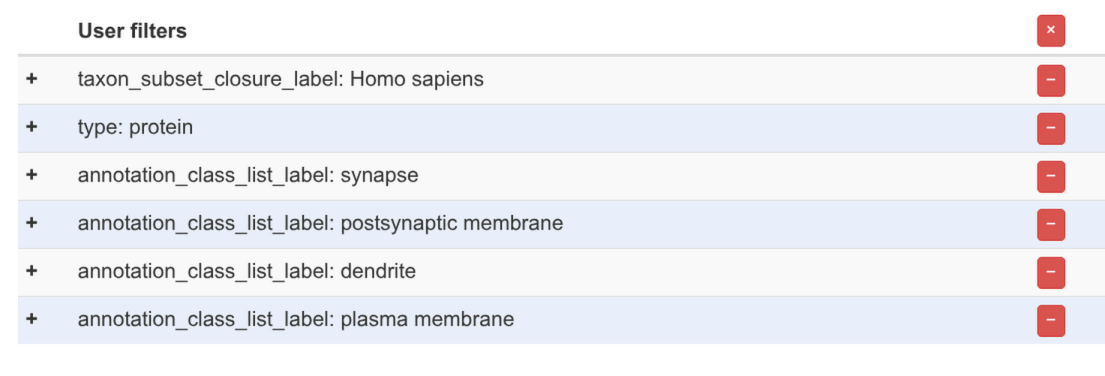

In [ ]:
selection = ['DLG4', 'ASIC1', 'HTR2A', 'KCNC3', 'ARC', 'CHRM5', 'GABRG2', 'GABRB1', 'GRM2', 'KCNB1', 'SEMA4F', 'CHRM4', 'CHRM2', 'GRIA1', 'GRIA2', 'CHRNA3', 'DRD1', 'GRIN1', 'CHRM1', 'GABRA5', 'CLCN2', 'GLRB', 'GLRA3', 'GABRA2', 'GRIP1', 'KCNH1', 'SYAP1', 'PCDH8', 'TRAPPC4', 'NLGN2', 'DRD2', 'GRM1', 'EPHA4', 'SYNDIG1', 'TENM2', 'GRIK3', 'GRIK2', 'KCNC2', 'KCND2', 'GRIN2B', 'LHFPL4', 'NECTIN3', 'CACNA1C', 'GRIA4', 'CLSTN2', 'DDN', 'KCNK2', 'LRFN3', 'CNIH2', 'CLSTN3', 'SORCS2', 'NLGN1', 'NLGN4X', 'ANK3', 'GPHN', 'FMR1', 'SLC8A3', 'GNB5', 'GABBR1', 'KCNA2', 'RAC1', 'CNIH3', 'CHRNA7', 'GPR179', 'KCNC1', 'PRR7', 'CHRNA4', 'CHRM3', 'ADORA1', 'SHANK1', 'AKAP5', 'GLRA1']
matching_selection = [gene for gene in selection if gene in expression.columns]

In [ ]:
d = expression.loc[group['roi_template'], matching_selection]
assert np.array_equal(d.index, group['roi_template'])
expression_average = d.median(axis=1).to_numpy()

In [ ]:
fig, axs = plt.subplots(1,4, figsize=(20*CM,5*CM), sharex=True, constrained_layout=True)
axs=axs.flatten()
sns.regplot(x=expression_average, y=deg, ax=axs[0], robust=True, **params)
sns.regplot(x=expression_average, y=deg_undir, ax=axs[1], robust=True, **params)
sns.regplot(x=expression_average, y=deg_in, ax=axs[2], robust=True, **params)
sns.regplot(x=expression_average, y=deg_out, ax=axs[3], robust=True, **params)

In [ ]:
selection = np.loadtxt('/RAID1/jupytertmp/mcm/data/external/genesets/human-synapse.txt', dtype=str)
matching_selection = [gene for gene in selection if gene in expression.columns]

d = expression.loc[group['roi_template'], matching_selection]
assert np.array_equal(d.index, group['roi_template'])
expression_average = d.median(axis=1).to_numpy()

In [ ]:
fig, axs = plt.subplots(1,3, figsize=(15*CM,5*CM), sharex=True, constrained_layout=True)
axs=axs.flatten()
sns.regplot(x=expression_average, y=deg_undir, ax=axs[0], **params)
sns.regplot(x=expression_average, y=deg_in, ax=axs[1], **params)
sns.regplot(x=expression_average, y=deg_out, ax=axs[2], **params)

In [ ]:
selection = np.loadtxt('/RAID1/jupytertmp/mcm/data/external/genesets/human-synapse-prepost.txt', dtype=str)
matching_selection = [gene for gene in selection if gene in expression.columns]

d = expression.loc[group['roi_template'], matching_selection]
assert np.array_equal(d.index, group['roi_template'])
expression_average = d.median(axis=1).to_numpy()

In [ ]:
fig, axs = plt.subplots(1,3, figsize=(15*CM,5*CM), sharex=True, constrained_layout=True)
axs=axs.flatten()
sns.regplot(x=expression_average, y=deg_undir, ax=axs[0], robust=True, **params)
sns.regplot(x=expression_average, y=deg_in, ax=axs[1], robust=True, **params)
sns.regplot(x=expression_average, y=deg_out, ax=axs[2], robust=True, **params)

---

# 7. Stats

In [ ]:
thr = 0.7

null_distribution = []

for i in range(1, 10001):

    arrays = []
    for cohort in ['tum', 'hcp']:
        with np.load(f'/RAID1/jupytertmp/mcm/data/null-models/{cohort}/directed/directed_null-{i:05}.npz') as data:
            null = data['arr_0']
        null_thr = bct.threshold_proportional(null, thr)
        null_thr_vec = pymcm.array.vectorize_matrix(null_thr)
        arrays.append(null_thr_vec)

    null_tum, null_hcp = arrays
    non0_mask = (null_tum != 0) & (null_hcp != 0)
    null_tum = null_tum[non0_mask]
    null_hcp = null_hcp[non0_mask]

    r, p = stats.pearsonr(null_tum, null_hcp)
    null_distribution.append(r)

    print(i, end='\r')

In [ ]:
ax = sns.kdeplot(null_distribution, fill=True)

In [ ]:
stats.percentileofscore(null_distribution, 0.48)

# 8. Appendix: CMRGlc template validation

In [19]:
import os
if not 'workbench' in os.environ['PATH']:
    os.environ['PATH'] += ':/home/tumnic/rbelenya/workbench/bin_linux64'

In [111]:
raichle_fsaverage = transforms.fslr_to_fsaverage(
    data=fetch_annotation(source='raichle', desc='cmrglc', space='fsLR', den='164k'), 
    target_density='164k', 
    hemi=('L', 'R')
)

mesh = surface.PolyMesh(
    left=fsaverage['infl_left'],
    right=fsaverage['infl_right'],
)

raichle_surf = surface.SurfaceImage(
    mesh=mesh,
    data=surface.PolyData(
        left=raichle_fsaverage[0].agg_data(),
        right=raichle_fsaverage[1].agg_data(),
    )
)

sch_left = nib.freesurfer.read_annot('/RAID1/jupytertmp/mcm/data/external/schaefer/fsaverage/lh.Schaefer2018_400Parcels_7Networks_order.annot')[0]
sch_right = nib.freesurfer.read_annot('/RAID1/jupytertmp/mcm/data/external/schaefer/fsaverage/rh.Schaefer2018_400Parcels_7Networks_order.annot')[0]
schaefer_surf = surface.SurfaceImage(
    mesh=mesh,
    data=surface.PolyData(
        left=np.array(sch_left, dtype=np.int32),
        right=np.where(sch_right > 0, sch_right+500, 0),
    )
)

cmrglc_surf = surface.SurfaceImage(
    mesh=mesh,
    data=surface.PolyData(
        left=np.array(nib.load('/RAID1/jupytertmp/mcm/data/cmrglc-maps/quant-cmrglc_desc-10frames_hemi-lh_space-fsaverage_pet.mgh').get_fdata()).squeeze(),
        right=np.array(nib.load('/RAID1/jupytertmp/mcm/data/cmrglc-maps/quant-cmrglc_desc-10frames_hemi-rh_space-fsaverage_pet.mgh').get_fdata()).squeeze(),
    )
)


castrillon_vol = fetch_annotation(source='castrillon2023')

cmrglc_vol = '/RAID1/jupytertmp/mcm/data/cmrglc-maps/quant-cmrglc_res-1mm_desc-10frames_space-mni1mm_pet.nii.gz'
schaefer_vol = '/RAID1/jupytertmp/mcm/data/external/schaefer/Schaefer2018_400Parcels_7Networks_order_FSLMNI152_1mm.nii.gz'
mni_brain_vol = ''

masker_vol = maskers.NiftiLabelsMasker(labels_img=schaefer_vol, resampling_target='data')
masker_surf = maskers.SurfaceLabelsMasker(labels_img=schaefer_surf)


[References] Please cite the following papers if you are using this data:

  For {'source': 'raichle', 'desc': 'cmrglc', 'space': 'fsLR', 'den': '164k'}:
  [primary]:
    S Neil Vaishnavi, Andrei G Vlassenko, Melissa M Rundle, Abraham Z Snyder, Mark A Mintun, and Marcus E Raichle. Regional aerobic glycolysis in the human brain. Proceedings of the National Academy of Sciences, 107(41):17757–17762, 2010.
  [secondary]:
    

[References] Please cite the following papers if you are using this data:

  For {'source': 'castrillon2023', 'desc': 'cmrglc', 'space': 'MNI152', 'res': '3mm'}:
  [primary]:
    Gabriel Castrillon, Samira Epp, Antonia Bose, Laura Fraticelli, André Hechler, Roman Belenya, Andreas Ranft, Igor Yakushev, Lukas Utz, Lalith Sundar, and others. An energy costly architecture of neuromodulators for human brain evolution and cognition. Science advances, 9(50):eadi7632, 2023.
  [secondary]:
    


In [112]:
params = {
    'scatter_kws': dict(marker='.', s=5, alpha=0.8, edgecolor='none', facecolor='.2', zorder=5),
    'line_kws': dict(color='crimson', zorder=6, lw=1)
}

In [113]:
cmrglc_rois_surf = masker_surf.fit_transform(cmrglc_surf).squeeze()
raichle_rois_surf = masker_surf.fit_transform(raichle_surf).squeeze()

cmrglc_rois_vol = masker_vol.fit_transform(cmrglc_vol).squeeze()
castrillon_rois_vol = masker_vol.fit_transform(castrillon_vol).squeeze()

In [172]:
test_vol_surf = stats.pearsonr(cmrglc_rois_vol, cmrglc_rois_surf)
test_vol = stats.pearsonr(cmrglc_rois_vol, castrillon_rois_vol)
test_surf = stats.pearsonr(cmrglc_rois_surf, raichle_rois_surf)

Text(0.3, 0.6, 'r = 0.74')

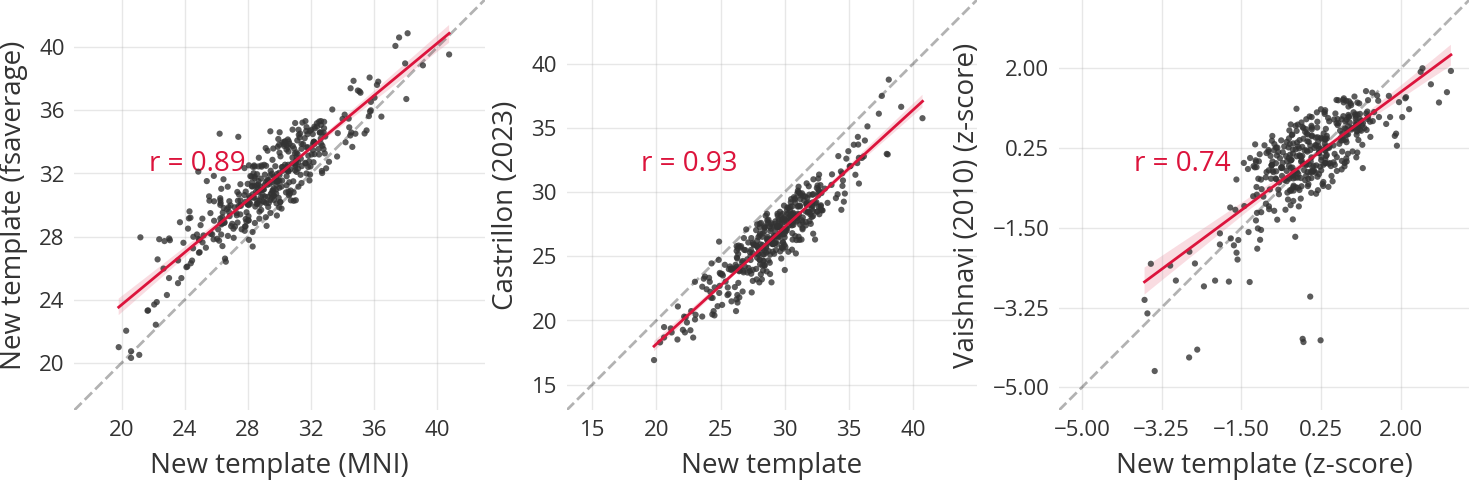

In [178]:
fig, axs = plt.subplots(1,3, figsize=(9,3))

sns.regplot(x=cmrglc_rois_vol, y=cmrglc_rois_surf, ax=axs[0], **params)
sns.regplot(x=cmrglc_rois_vol, y=castrillon_rois_vol, ax=axs[1], **params)
sns.regplot(x=stats.zscore(cmrglc_rois_surf), y=stats.zscore(raichle_rois_surf), ax=axs[2], **params)


axs[0].axline((15,15), slope=1, linewidth=1, color='k', linestyle='--', alpha=0.3)
axs[0].set(xticks=np.linspace(20, 40, 6), yticks=np.linspace(20, 40, 6), xlim=(17, 43), ylim=(17, 43))

axs[1].axline((15,15), slope=1, linewidth=1, color='k', linestyle='--', alpha=0.3)
axs[1].set(xticks=np.linspace(15, 40, 6), yticks=np.linspace(15, 40, 6), xlim=(13, 45), ylim=(13, 45))

axs[2].set(xticks=np.linspace(-5, 2, 5), yticks=np.linspace(-5, 2, 5), xlim=(-5.5, 3.5), ylim=(-5.5, 3.5))
axs[2].axline((-6,-6), slope=1, linewidth=1, color='k', linestyle='--', alpha=0.3)

for ax in axs:
    ax.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
    ax.grid(zorder=0, linewidth=0.5, alpha=0.3)
    ax.set(xlabel=None, ylabel=None)
    ax.tick_params(axis='both', which='both', length=0)
    ax.set_aspect('equal')

axs[0].set(xlabel='New template (MNI)', ylabel='New template (fsaverage)')
axs[1].set(xlabel='New template', ylabel='Castrillon (2023)')
axs[2].set(xlabel='New template (z-score)', ylabel='Vaishnavi (2010) (z-score)')

axs[0].text(0.3, 0.6, f'r = {test_vol_surf.statistic:.2f}', color='crimson', transform=axs[0].transAxes, va='center', ha='center')
axs[1].text(0.3, 0.6, f'r = {test_vol.statistic:.2f}', color='crimson', transform=axs[1].transAxes, va='center', ha='center')
axs[2].text(0.3, 0.6, f'r = {test_surf.statistic:.2f}', color='crimson', transform=axs[2].transAxes, va='center', ha='center')



In [119]:
dl = np.loadtxt('/RAID1/jupytertmp/mcm/data/fsa5-geodistance/lh.Schaefer2018_400Parcels_7Networks_geodistance.txt', delimiter=',')
dr = np.loadtxt('/RAID1/jupytertmp/mcm/data/fsa5-geodistance/rh.Schaefer2018_400Parcels_7Networks_geodistance.txt', delimiter=',')

schaefer_distance = {
    'left': np.loadtxt('/RAID1/jupytertmp/mcm/data/fsa5-geodistance/lh.Schaefer2018_400Parcels_7Networks_geodistance.txt', delimiter=','),
    'right': np.loadtxt('/RAID1/jupytertmp/mcm/data/fsa5-geodistance/rh.Schaefer2018_400Parcels_7Networks_geodistance.txt', delimiter=','),
}

In [120]:
vol_true = {key: value for key, value in zip(['left', 'right'], np.split(cmrglc_rois_vol, 2))}

vol_surrogate_maps = {
    'left': Base(vol_true['left'], schaefer_distance['left'], resample=False)(n=1000),
    'right': Base(vol_true['right'], schaefer_distance['right'], resample=False)(n=1000)
}

In [146]:
castrillon_hemis = {key: value for key, value in zip(['left', 'right'], np.split(castrillon_rois_vol, 2))}

for hemi in ['left', 'right']:

    test = stats.pearsonr(vol_true[hemi], castrillon_hemis[hemi])
    distribution = pymcm.array.corr_2d(vol_surrogate_maps[hemi], castrillon_hemis[hemi][:, np.newaxis]).squeeze()
    pvalue = nonparp(test.statistic, distribution)
    print(f'{pvalue:.5f}')

0.00000
0.00000


In [174]:
cmrglc_surf_hemis = {key: value for key, value in zip(['left', 'right'], np.split(cmrglc_rois_surf, 2))}

for hemi in ['left', 'right']:

    test = stats.pearsonr(vol_true[hemi], cmrglc_surf_hemis[hemi])
    distribution = pymcm.array.corr_2d(vol_surrogate_maps[hemi], cmrglc_surf_hemis[hemi][:, np.newaxis]).squeeze()
    pvalue = nonparp(test.statistic, distribution)
    print(f'{pvalue:.5f}')

0.00000
0.00000


In [139]:
surf_true = {key: value for key, value in zip(['left', 'right'], np.split(cmrglc_rois_surf, 2))}

surf_surrogate_maps = {
    'left': Base(surf_true['left'], schaefer_distance['left'], resample=False)(n=1000),
    'right': Base(surf_true['right'], schaefer_distance['right'], resample=False)(n=1000)
}

In [145]:
raichle_hemis = {key: value for key, value in zip(['left', 'right'], np.split(raichle_rois_surf, 2))}

for hemi in ['left', 'right']:

    test = stats.pearsonr(surf_true[hemi], raichle_hemis[hemi])
    distribution = pymcm.array.corr_2d(surf_surrogate_maps[hemi], raichle_hemis[hemi][:, np.newaxis]).squeeze()
    pvalue = nonparp(test.statistic, distribution)
    print(f'{pvalue:.5f}')

0.00000
0.00000


In [143]:
print(f'{pvalue:.5f}')

0.00000


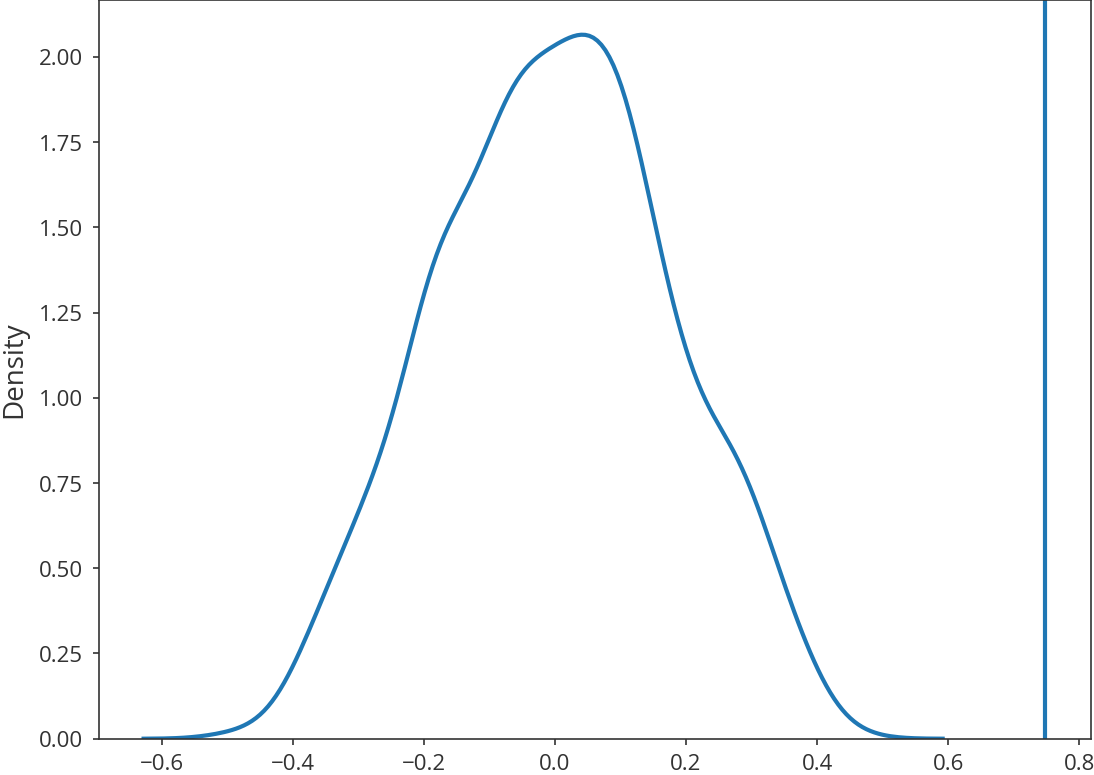

In [144]:
ax = sns.kdeplot(distribution)
ax.axvline(test.statistic)

---